# Staged Data QA
**BRIM Systems** | Prepared by: Brian Rimmer

---

## Purpose

Validation and exploration pass against dbt staging model output. Confirms that staging
transformations resolved the issues identified in `raw_profiling.ipynb`, and surfaces
any remaining issues before intermediate models are built.

**Section flow:**
1. Configuration & Data Loading
2. Staged Data Summary (head preview + schema & null flags)
3. Known-Value Validation
4. Exploration & Visualization (numeric, categorical, correlation, time series)
5. Structural Integrity Checks (PK, RI & join viability, FK null rates)
6. Additional Analyses (numeric range, temporal gap detection)

**Sequencing:**
```
raw_profiling.ipynb  ->  dbt staging models  ->  staged_qa.ipynb  (this file)
        ->  int_analysis.ipynb  ->  dbt intermediate + mart models
```

Run after `dbt run --select staging` has completed successfully.

---

> **Note for reviewers:** This is a read-only validation artifact. No files are written to disk.

## 0. Environment Setup

In [1]:
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import linregress

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

BRAND_BLUE   = "#3D5166"
BRAND_ACCENT = "#6B8FA8"
WARN_AMBER   = "#D4881E"
FAIL_RED     = "#B94040"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC", "axes.grid": True,
    "grid.color": "#EEEEEE", "grid.linestyle": "-",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.dpi": 120,
})

print("Environment ready.")

Environment ready.


## 1. Configuration & Data Loading

Universal configuration shared across all sections. Variables specific to an
individual analysis are defined at the top of that section.

**Shared with `raw_profiling.ipynb`** — keep null thresholds in sync.
**What to update for a new project** — `DB_PATH`, all `TBL_STG_*` constants,
and all config dicts below.

In [2]:
# ── Shared with raw_profiling.ipynb — keep in sync ────────────────────────
TBL_MACHINES          = "machines"
TBL_OPERATORS         = "operators"
TBL_MATERIAL_LOTS     = "material_lots"
TBL_PART_CATALOG      = "part_catalog"
TBL_PRODUCTION_ORDERS = "production_orders"
TBL_INSPECTION_REC    = "inspection_records"
TBL_SCRAP_EVENTS      = "scrap_events"


# ── Database connection ────────────────────────────────────────────────────
DB_PATH = Path("../data/defects_scrap.duckdb").resolve()

# ── Staged table name constants ───────────────────────────────────────────
TBL_STG_MACHINES  = "stg_mes__machines"
TBL_STG_OPERATORS = "stg_hr__operators"
TBL_STG_LOTS      = "stg_materials__lots"
TBL_STG_PARTS     = "stg_erp__part_catalog"
TBL_STG_ORDERS    = "stg_erp__production_orders"
TBL_STG_INSP      = "stg_qms__inspection_records"
TBL_STG_SCRAP     = "stg_qms__scrap_events"

TABLES = {
    TBL_STG_MACHINES:  TBL_STG_MACHINES,
    TBL_STG_OPERATORS: TBL_STG_OPERATORS,
    TBL_STG_LOTS:      TBL_STG_LOTS,
    TBL_STG_PARTS:     TBL_STG_PARTS,
    TBL_STG_ORDERS:    TBL_STG_ORDERS,
    TBL_STG_INSP:      TBL_STG_INSP,
    TBL_STG_SCRAP:     TBL_STG_SCRAP,
}

# ── Primary keys ───────────────────────────────────────────────────────────
PK_MAP = {
    TBL_STG_MACHINES:  "machine_id",
    TBL_STG_OPERATORS: "operator_id",
    TBL_STG_LOTS:      "lot_id",
    TBL_STG_PARTS:     "part_number",
    TBL_STG_ORDERS:    "work_order_id",
    TBL_STG_INSP:      "inspection_id",
    TBL_STG_SCRAP:     "scrap_id",
}

# ── Foreign key relationships ─────────────────────────────────────────────
# (child_table, child_col, parent_table, parent_col)
FK_RELATIONSHIPS = [
    (TBL_STG_ORDERS, "machine_id",    TBL_STG_MACHINES,  "machine_id"),
    (TBL_STG_ORDERS, "operator_id",   TBL_STG_OPERATORS, "operator_id"),
    (TBL_STG_ORDERS, "part_number",   TBL_STG_PARTS,     "part_number"),
    (TBL_STG_ORDERS, "lot_id",        TBL_STG_LOTS,      "lot_id"),
    (TBL_STG_INSP,   "work_order_id", TBL_STG_ORDERS,    "work_order_id"),
    (TBL_STG_SCRAP,  "work_order_id", TBL_STG_ORDERS,    "work_order_id"),
    (TBL_STG_SCRAP,  "inspection_id", TBL_STG_INSP,      "inspection_id"),
]

# ── FK columns expected to be partially null (structural nulls) ───────────
FK_NULLABLE = {
    (TBL_STG_ORDERS, "lot_id"),  # material not always scanned at job start
}


# ── Load staged tables from DuckDB ────────────────────────────────────────
dfs = {}

if not DB_PATH.exists():
    print(f"  ✗  DuckDB file not found: {DB_PATH}")
    print("     Run: dbt run --select staging")
else:
    con = duckdb.connect(str(DB_PATH), read_only=True)
    print(f"{'Table':<38} {'Rows':>8}  {'Cols':>5}  Status")
    print("-" * 65)
    for name, view_name in TABLES.items():
        try:
            df = con.execute(f"SELECT * FROM main.{view_name}").df()
            dfs[name] = df
            print(f"  ✓  {name:<35} {len(df):>8,}  {len(df.columns):>5}")
        except Exception as e:
            print(f"  ✗  {name:<35} ERROR: {e}")
    con.close()

orders = dfs.get(TBL_STG_ORDERS)
insp   = dfs.get(TBL_STG_INSP)
scrap  = dfs.get(TBL_STG_SCRAP)
mach   = dfs.get(TBL_STG_MACHINES)
ops    = dfs.get(TBL_STG_OPERATORS)
lots   = dfs.get(TBL_STG_LOTS)
parts  = dfs.get(TBL_STG_PARTS)

Table                                      Rows   Cols  Status
-----------------------------------------------------------------
  ✓  stg_mes__machines                          7      5
  ✓  stg_hr__operators                         20      7
  ✓  stg_materials__lots                      920      8
  ✓  stg_erp__part_catalog                     35      8


  ✓  stg_erp__production_orders             8,597     18


  ✓  stg_qms__inspection_records            8,597     12


  ✓  stg_qms__scrap_events                  7,948     17


---
## 2. Staged Data Summary

### 2.1 Preview

In [3]:
for tbl, df in dfs.items():
    full_dups = df.duplicated(keep=False).sum()
    dup_str   = f"{full_dups:,}" if full_dups > 0 else "none"
    print(f"\n{'='*70}")
    print(f"  {tbl.upper()}  ({len(df):,} rows  x  {len(df.columns)} columns)  |  Full duplicates: {dup_str}")
    print(f"{'='*70}")
    display(df.head())


  STG_MES__MACHINES  (7 rows  x  5 columns)  |  Full duplicates: none


,machine_id,machine_name,machine_type,age_years,location
0,M01,Laser Cutter 1,Laser Cutting,3,Bay A
1,M02,Laser Cutter 2,Laser Cutting,8,Bay A
2,M03,Press Brake 1,Bending,12,Bay B
3,M04,Press Brake 2,Bending,2,Bay B
4,M05,Welding Station 1,Welding,6,Bay C



  STG_HR__OPERATORS  (20 rows  x  7 columns)  |  Full duplicates: none


,operator_id,operator_name,shift,hire_date,cert_level,specialization,welding_cert_current
0,OP001,Allison Hill,Shift B,2026-03-26,Level 2,Welding,True
1,OP002,Noah Rhodes,Shift A,2022-01-14,Level 3,General,True
2,OP003,Angie Henderson,Shift B,2021-01-15,Level 2,General,True
3,OP004,Daniel Wagner,Shift A,2022-07-28,Level 2,Bending,True
4,OP005,Cristian Santos,Shift A,2024-06-21,Level 1,Bending,True



  STG_MATERIALS__LOTS  (920 rows  x  8 columns)  |  Full duplicates: none


...

,work_order_id,part_number,part_number_raw,customer,quantity_ordered,machine_id,operator_id,operator_id_raw,shift_code,lot_id,lot_id_raw,order_date,scheduled_start,actual_start,complexity,material_type,requires_welding,std_labor_hrs
0,WO-10000,P-1001,P-1001,Customer A,25,M07,OP007,OP007,Shift B,None,None,2023-01-02,2023-01-02 14:08:00,2023-01-02 14:37:00,Medium,16ga Steel,True,1.0200
1,WO-10001,P-1032,P-1032,Customer F,152,M06,OP019,OP019,Shift A,None,None,2023-01-02,2023-01-02 07:14:00,2023-01-02 07:14:00,Medium,Aluminum 5052,False,2.0200
2,WO-10002,P-1010,P-1010,Customer A,59,M03,OP010,OP010,Shift B,None,None,2023-01-02,2023-01-02 14:22:00,2023-01-02 15:06:00,Low,Stainless 304,True,4.0800
3,WO-10003,P-1016,P1016,Customer G,434,M05,OP018,OP018,Shift A,LOT-1003,LOT-1003,2023-01-02,2023-01-02 06:19:00,2023-01-02 07:05:00,Low,14ga Steel,False,4.1300
4,WO-10004,P-1012,PART-1012,Customer D,453,M04,OP002,OP002,Shift A,None,None,2023-01-02,2023-01-02 06:30:00,2023-01-02 07:05:00,Medium,"3/8"" Plate",False,1.3900



  STG_QMS__INSPECTION_RECORDS  (8,597 rows  x  12 columns)  |  Full duplicates: none


,inspection_id,work_order_id,inspection_date,inspector_id,quantity_inspected,quantity_passed,quantity_failed,defect_code,defect_code_raw,disposition,notes,is_anomalous_timestamp
0,INSP-5,WO-10004,2023-01-02 11:42:55.478027,OP018,453,433,20,Dimensional,Dimensional,Use-As-Is,None,False
1,INSP-6,WO-10005,2023-01-02 18:25:00.019988,OP019,283,271,12,Burr,BURR,Rework,Before another body physical society instead as.,False
2,INSP-8,WO-10007,2023-01-03 16:56:54.996373,OP009,212,197,15,Dimensional,Dimentional,Use-As-Is,None,False
3,INSP-9,WO-10008,2023-01-03 11:39:51.854126,OP013,80,75,5,Weld Defect,weld defect,Use-As-Is,None,False
4,INSP-11,WO-10010,2023-01-03 19:57:35.137372,OP011,394,381,13,Bend Angle,BEND,Rework,None,False



  STG_QMS__SCRAP_EVENTS  (7,948 rows  x  17 columns)  |  Full duplicates: none


,scrap_id,work_order_id,inspection_id,scrap_date,machine_id,operator_id,shift_code,material_type,lot_id,scrap_reason,scrap_reason_raw,defect_code,quantity_scrapped,quantity_reworked,material_cost_per_unit,labor_cost_per_unit,total_scrap_cost
0,SCRAP-1,WO-10000,INSP-1,2023-01-02 15:43:45.174234,M07,OP007,None,16ga Steel,None,SETUP_ERROR,First Article Fail,Dimensional,0,1,0.6900,20.1300,0.0000
1,SCRAP-2,WO-10001,INSP-2,2023-01-02 08:58:55.133478,M06,OP019,Shift A,Aluminum 5052,None,OPERATOR_ERROR,OPERATOR_ERROR,Weld Defect,9,4,6.0600,35.0000,369.5400
2,SCRAP-3,WO-10002,INSP-3,2023-01-02 17:59:16.221099,M03,OP010,Shift B,Stainless 304,None,OPERATOR_ERROR,Operator Error,Dimensional,4,9,2.1400,32.7900,139.7200
3,SCRAP-4,WO-10003,INSP-4,2023-01-02 09:20:01.515735,M05,OP018,Shift A,14ga Steel,LOT-1003,MACHINE_ISSUE,Mach Issue,Porosity,16,9,8.6100,28.0700,586.8800
4,SCRAP-5,WO-10005,INSP-6,2023-01-02 18:25:00.019988,M04,OP006,Shift B,"1/4"" Plate",LOT-1002,SETUP_ERROR,set up error,Burr,9,3,1.3000,49.3200,455.5800


### 2.2 Schema & Null Flags

In [4]:
# NULL THRESHOLDS
NULL_WARN_PCT = 0
NULL_FAIL_PCT = 10.0

In [5]:
def schema_summary(df):
    rows = []
    for col in df.columns:
        s        = df[col]
        null_ct  = s.isna().sum()
        null_pct = null_ct / len(df) * 100
        rows.append({
            "column":     col,
            "dtype":      str(s.dtype),
            "null_count": null_ct,
            "null_pct":   round(null_pct, 1),
            "n_unique":   s.nunique(dropna=True),
            "sample":     str(s.dropna().iloc[0])[:60] if null_ct < len(df) else "(all null)",
        })
    return pd.DataFrame(rows)

for tbl, df in dfs.items():
    print(f"\n{'='*70}\n  {tbl.upper()}  ({len(df):,} rows, {len(df.columns)} columns)\n{'='*70}")
    display(
        schema_summary(df).style
        .format({"null_pct": "{:.1f}%"})
        .applymap(
            lambda v: "background-color: #F8D7DA" if isinstance(v, float) and v > NULL_FAIL_PCT else
                      "background-color: #FFF3CD" if isinstance(v, float) and v > NULL_WARN_PCT else "",
            subset=["null_pct"]
        )
        .set_properties(**{"font-size": "11px"})
    )


  STG_MES__MACHINES  (7 rows, 5 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,machine_id,object,0,0.0%,7,M01
1,machine_name,object,0,0.0%,7,Laser Cutter 1
2,machine_type,object,0,0.0%,4,Laser Cutting
3,age_years,int32,0,0.0%,7,3
4,location,object,0,0.0%,3,Bay A



  STG_HR__OPERATORS  (20 rows, 7 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,operator_id,object,0,0.0%,20,OP001
1,operator_name,object,0,0.0%,20,Allison Hill
2,shift,object,0,0.0%,2,Shift B
3,hire_date,datetime64[us],0,0.0%,20,2026-03-26 00:00:00
4,cert_level,object,0,0.0%,3,Level 2
5,specialization,object,0,0.0%,4,Welding
6,welding_cert_current,bool,0,0.0%,2,True



  STG_MATERIALS__LOTS  (920 rows, 8 columns)


...

,column,dtype,null_count,null_pct,n_unique,sample
0,work_order_id,object,0,0.0%,8597,WO-10000
1,part_number,object,0,0.0%,35,P-1001
2,part_number_raw,object,0,0.0%,175,P-1001
3,customer,object,0,0.0%,8,Customer A
4,quantity_ordered,int32,0,0.0%,491,25
5,machine_id,object,0,0.0%,7,M07
6,operator_id,object,0,0.0%,20,OP007
7,operator_id_raw,object,0,0.0%,40,OP007
8,shift_code,object,0,0.0%,2,Shift B
9,lot_id,object,54,0.6%,876,LOT-1003



  STG_QMS__INSPECTION_RECORDS  (8,597 rows, 12 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,inspection_id,object,0,0.0%,8597,INSP-5
1,work_order_id,object,0,0.0%,8597,WO-10004
2,inspection_date,datetime64[us],0,0.0%,8597,2023-01-02 11:42:55.478027
3,inspector_id,object,0,0.0%,20,OP018
4,quantity_inspected,int32,0,0.0%,491,453
5,quantity_passed,int32,0,0.0%,477,433
6,quantity_failed,int32,0,0.0%,134,20
7,defect_code,object,0,0.0%,8,Dimensional
8,defect_code_raw,object,17,0.2%,55,Dimensional
9,disposition,object,0,0.0%,4,Use-As-Is



  STG_QMS__SCRAP_EVENTS  (7,948 rows, 17 columns)


,column,dtype,null_count,null_pct,n_unique,sample
0,scrap_id,object,0,0.0%,7948,SCRAP-1
1,work_order_id,object,0,0.0%,7340,WO-10000
2,inspection_id,object,0,0.0%,7948,INSP-1
3,scrap_date,datetime64[us],0,0.0%,7948,2023-01-02 15:43:45.174234
4,machine_id,object,0,0.0%,7,M07
5,operator_id,object,0,0.0%,20,OP007
6,shift_code,object,749,9.4%,2,Shift A
7,material_type,object,0,0.0%,7,16ga Steel
8,lot_id,object,54,0.7%,871,LOT-1003
9,scrap_reason,object,0,0.0%,6,SETUP_ERROR


---
## 3. Exploration & Visualization

In [6]:
# Auto-classify columns into numeric and categorical.
# Numeric: includes all int, float, complex dtypes ("number" is a pandas alias).
# Categorical: object and pandas Categorical dtypes, limited to <= 30 distinct values.
NUMERIC_COLS     = {}
CATEGORICAL_COLS = {}

for tbl, df in dfs.items():
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [
        c for c in df.select_dtypes(include=["object", "category"]).columns
        if df[c].nunique() <= 30
    ]
    if num_cols:
        NUMERIC_COLS[tbl]     = num_cols
    if cat_cols:
        CATEGORICAL_COLS[tbl] = cat_cols

print("Column classification:")
for tbl in dfs:
    n = len(NUMERIC_COLS.get(tbl, []))
    c = len(CATEGORICAL_COLS.get(tbl, []))
    print(f"  {tbl:<38} numeric: {n:>3}   categorical: {c:>3}")

Column classification:
  stg_mes__machines                      numeric:   1   categorical:   4
  stg_hr__operators                      numeric:   0   categorical:   5
  stg_materials__lots                    numeric:   2   categorical:   3
  stg_erp__part_catalog                  numeric:   2   categorical:   4
  stg_erp__production_orders             numeric:   2   categorical:   6
  stg_qms__inspection_records            numeric:   3   categorical:   3
  stg_qms__scrap_events                  numeric:   5   categorical:   6


### 3.1 Numeric Distributions

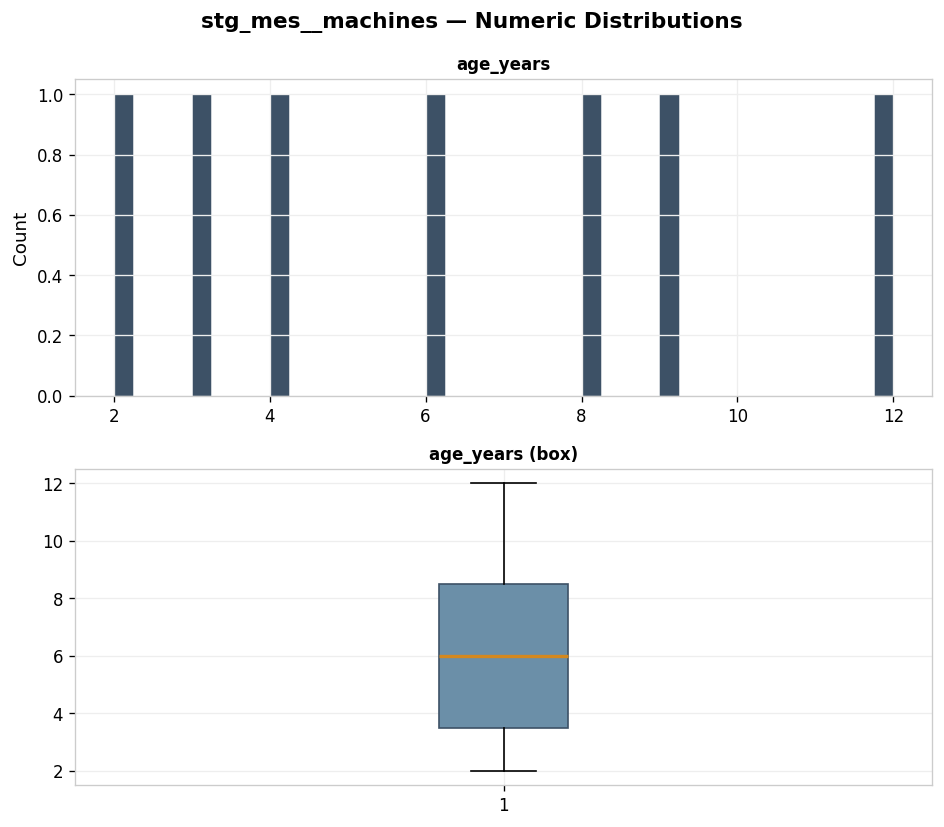

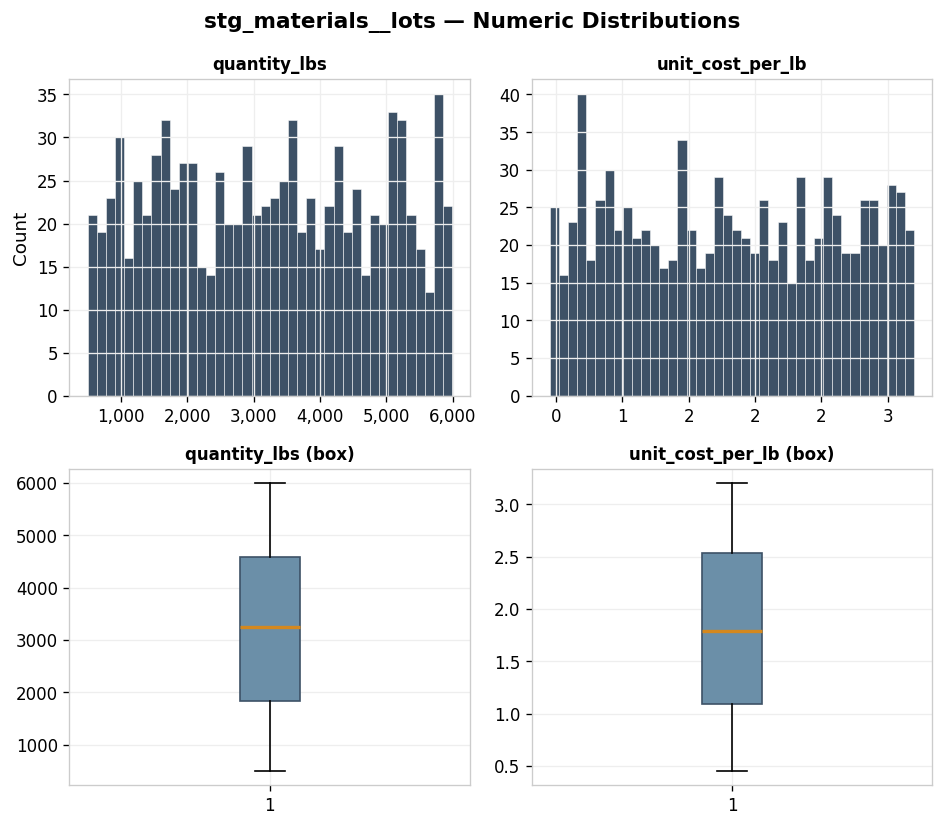

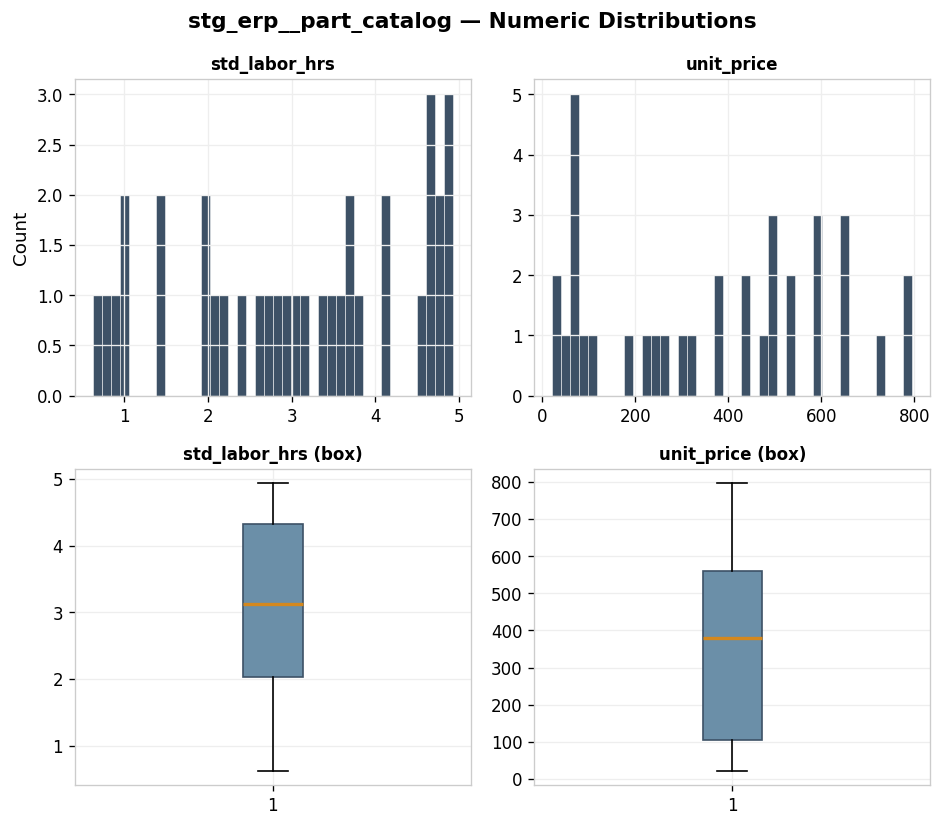

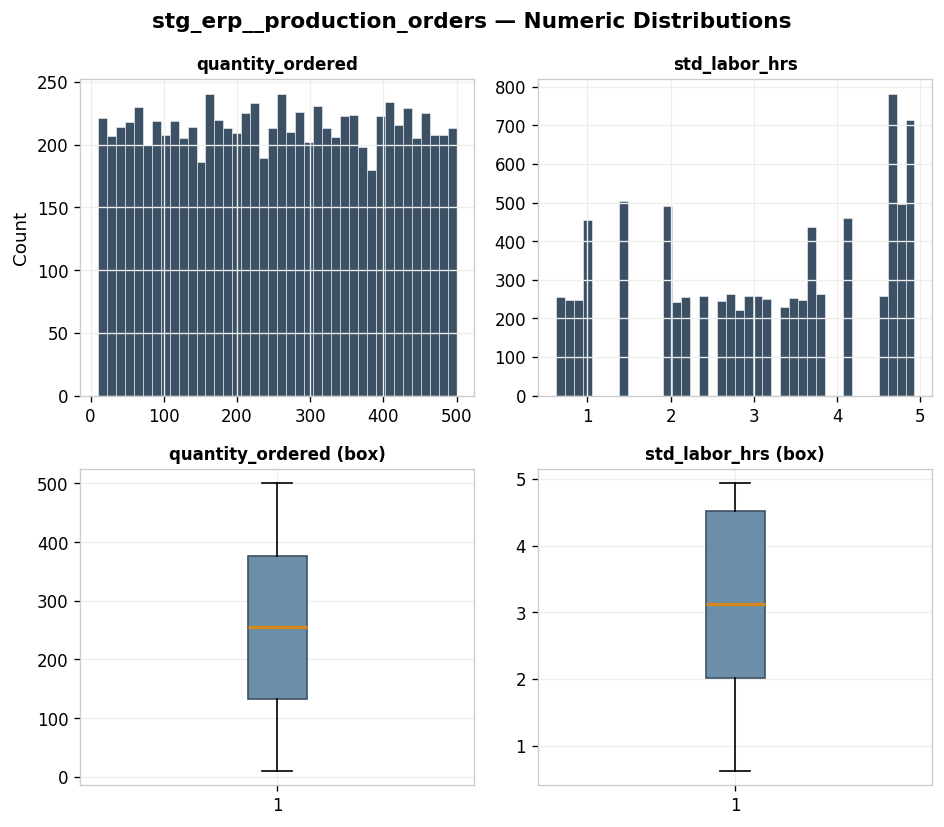

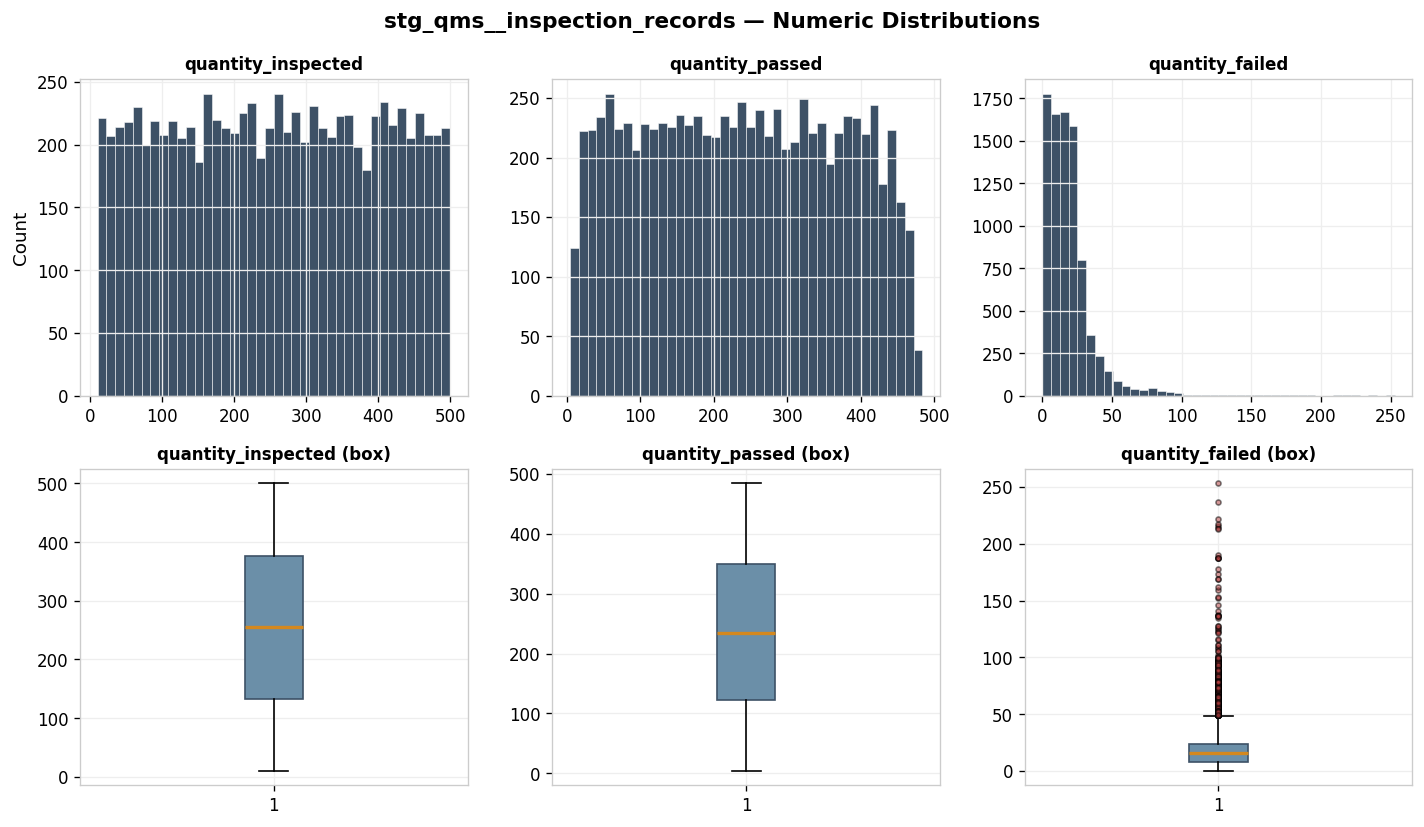

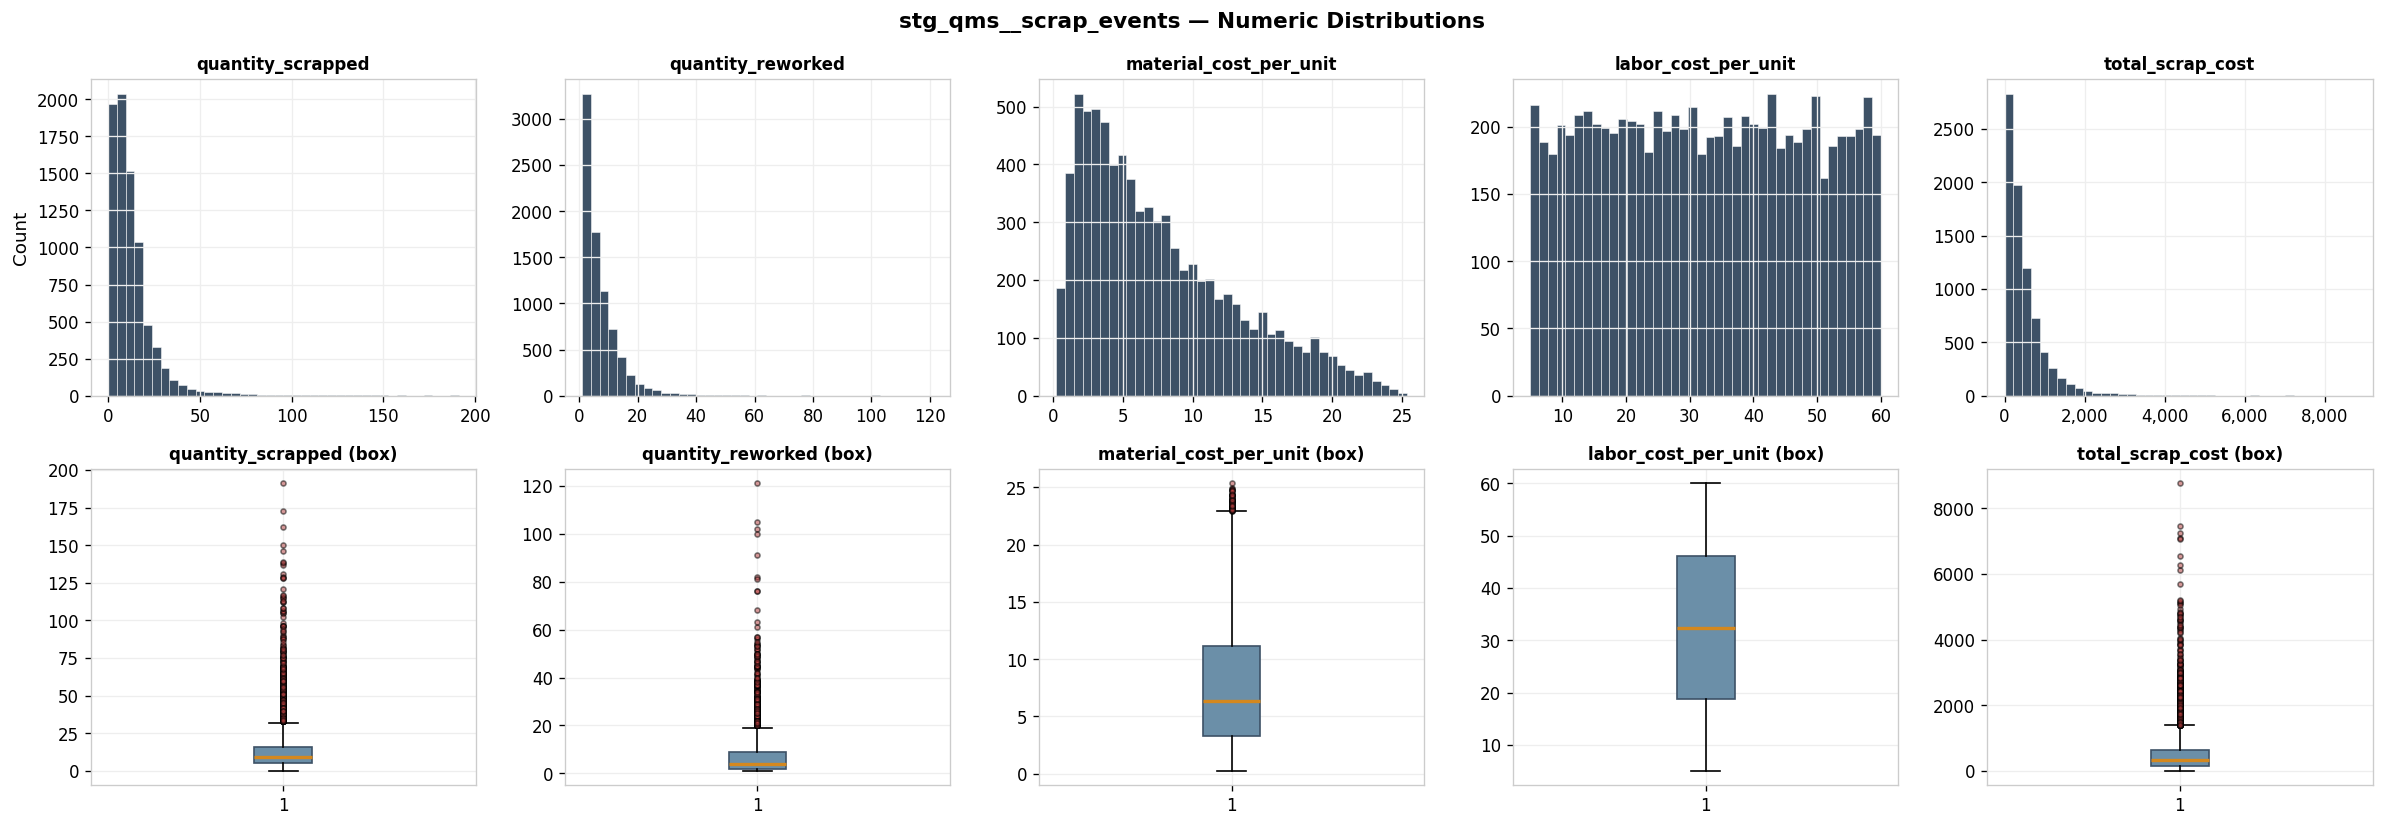

In [7]:
# Histogram + box plot per numeric column per table.
for tbl, cols in NUMERIC_COLS.items():
    df = dfs[tbl]
    n  = len(cols)
    if n == 0:
        continue
    fig, axes = plt.subplots(2, n, figsize=(max(4 * n, 8), 7))
    if n == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, col in enumerate(cols):
        s = df[col].dropna()
        axes[0, i].hist(s, bins=40, color=BRAND_BLUE, edgecolor="white", linewidth=0.3)
        axes[0, i].set_title(col, fontsize=10)
        axes[0, i].set_ylabel("Count" if i == 0 else "")
        axes[0, i].xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )
        axes[1, i].boxplot(s, vert=True, patch_artist=True,
                           boxprops=dict(facecolor=BRAND_ACCENT, color=BRAND_BLUE),
                           medianprops=dict(color=WARN_AMBER, linewidth=2),
                           flierprops=dict(marker="o", markersize=3,
                                          markerfacecolor=FAIL_RED, alpha=0.5))
        axes[1, i].set_title(f"{col} (box)", fontsize=10)

    fig.suptitle(f"{tbl} — Numeric Distributions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 3.2 Categorical Distributions

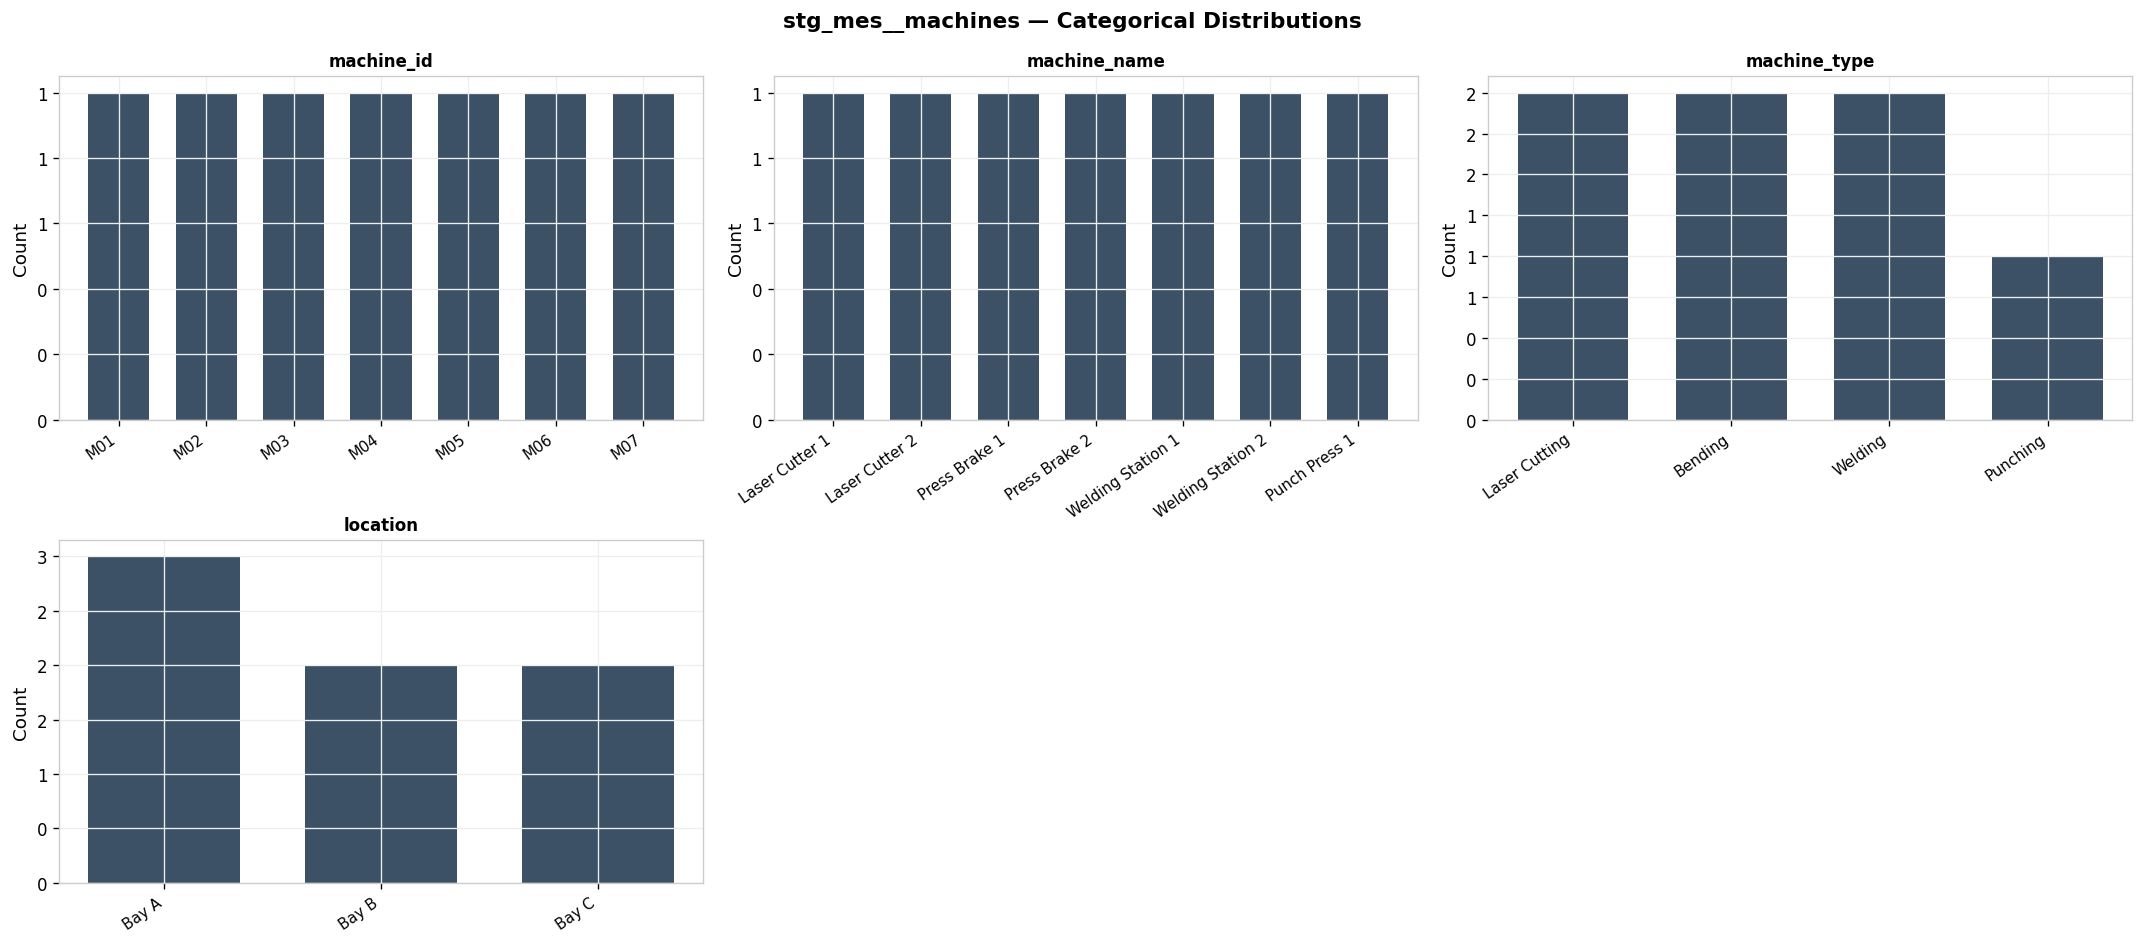

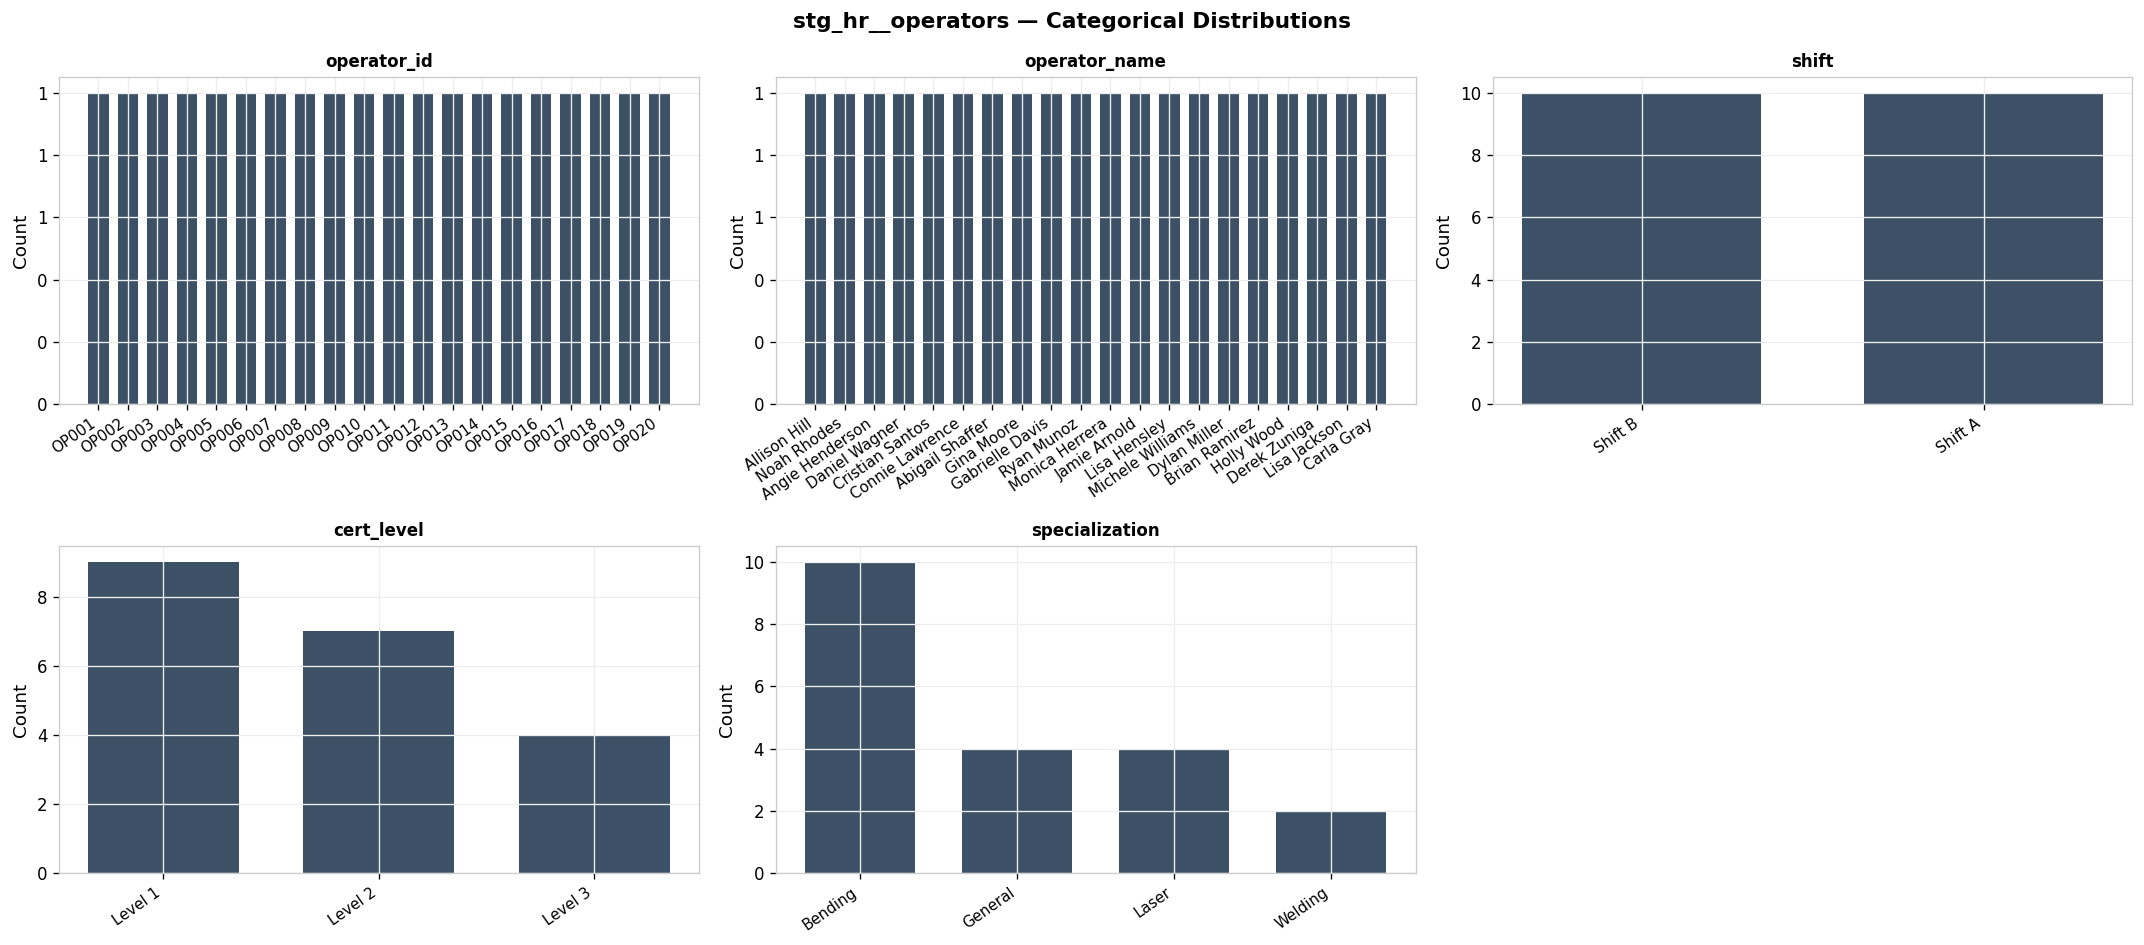

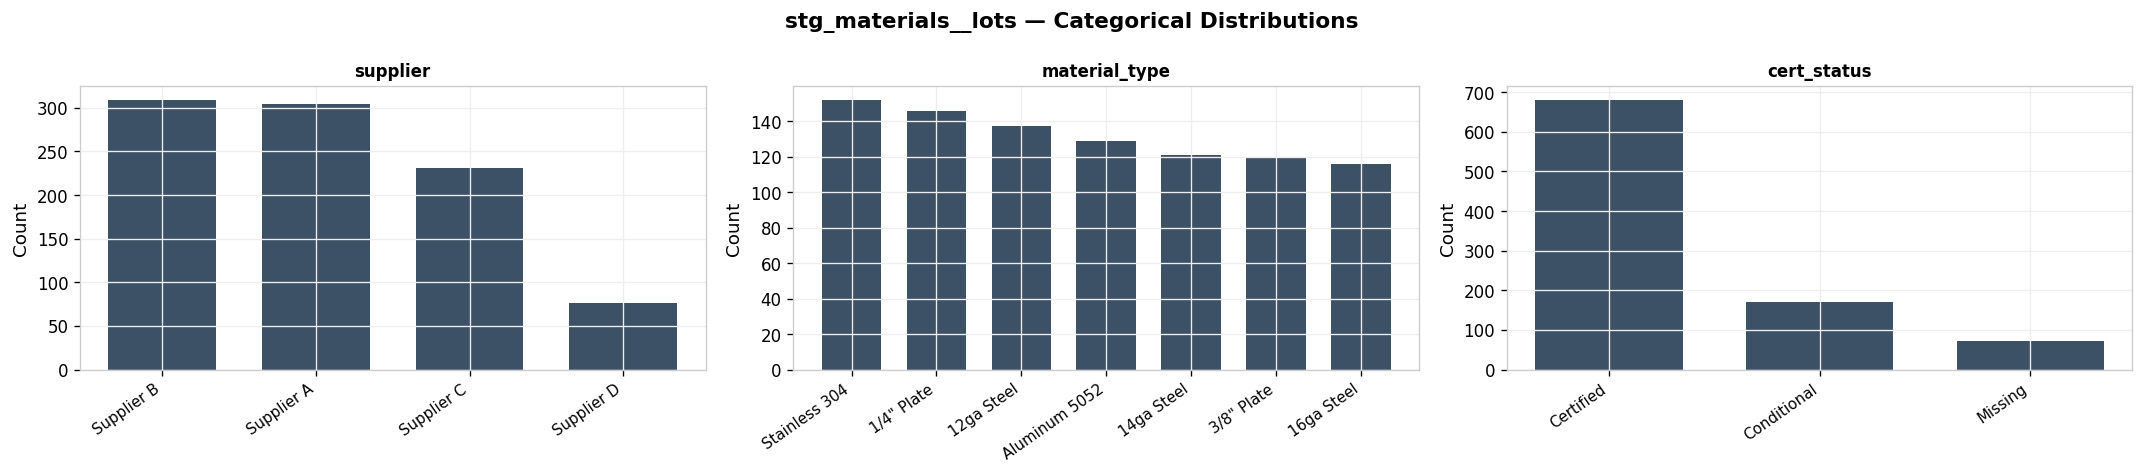

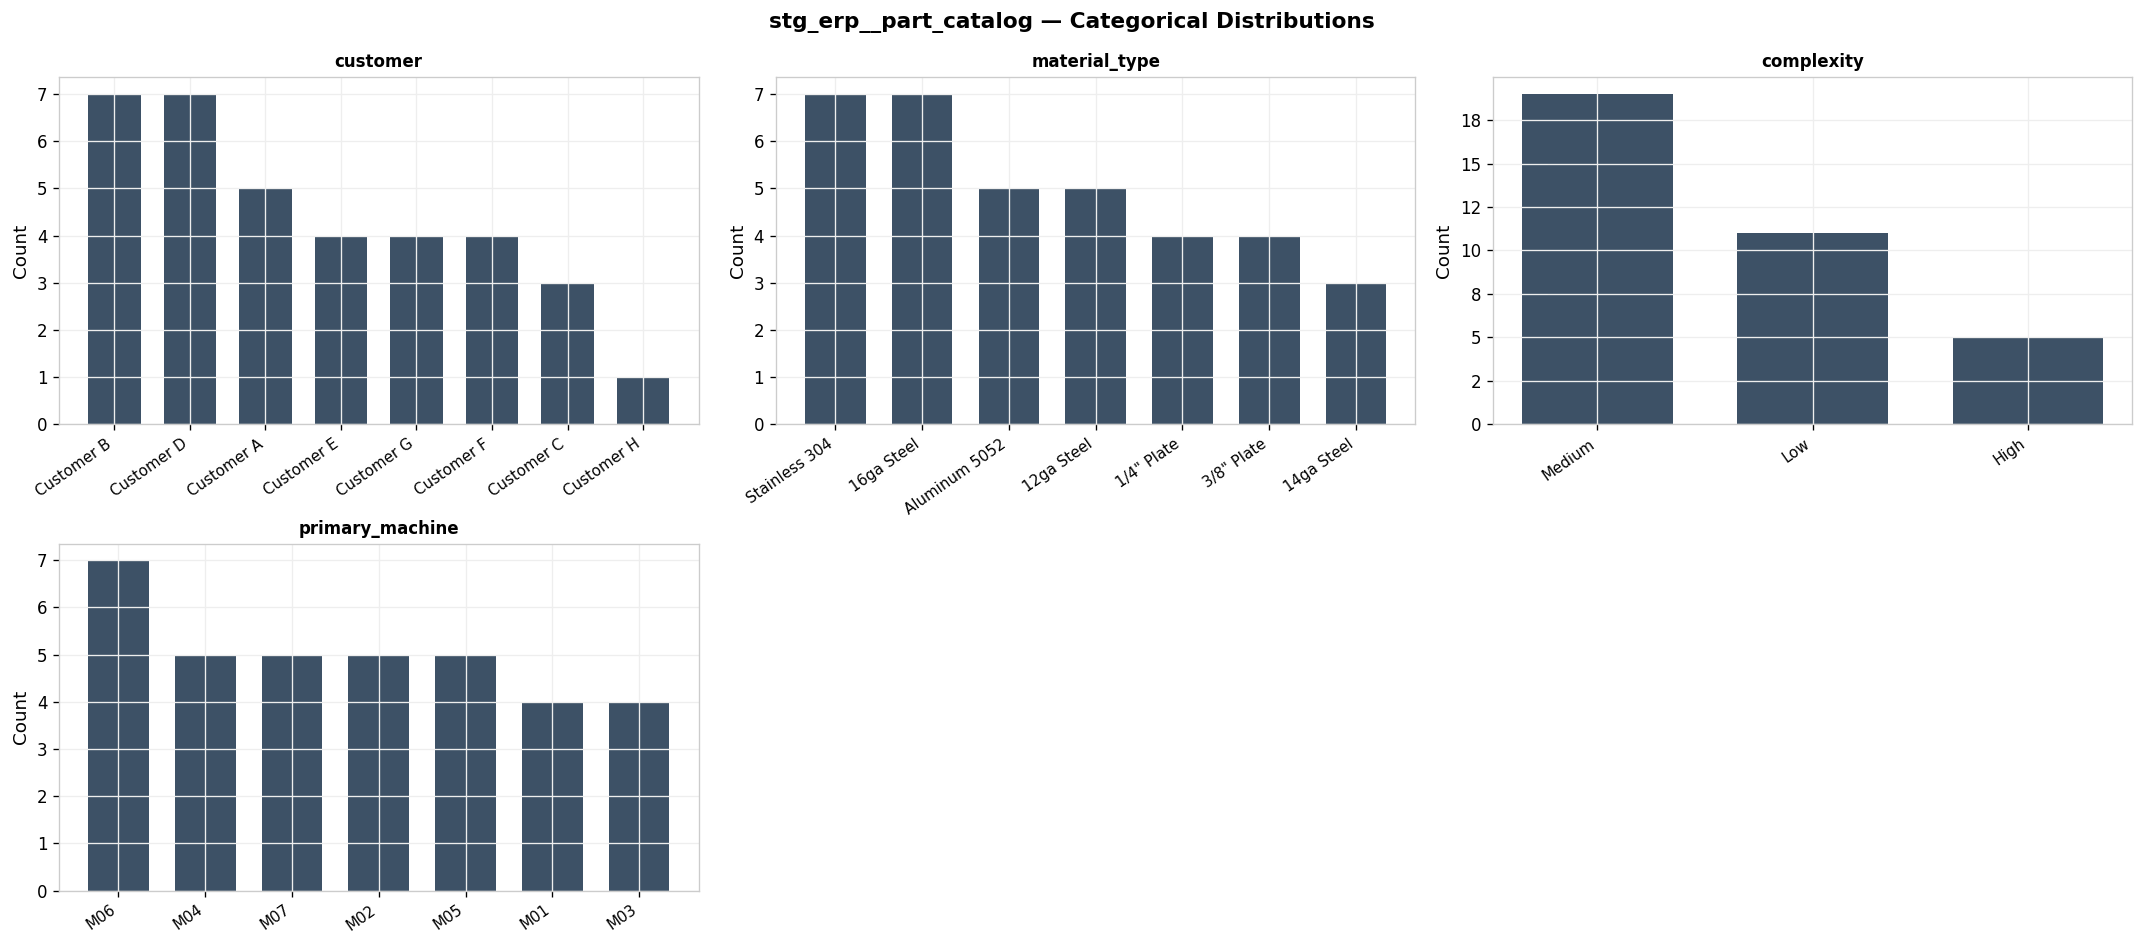

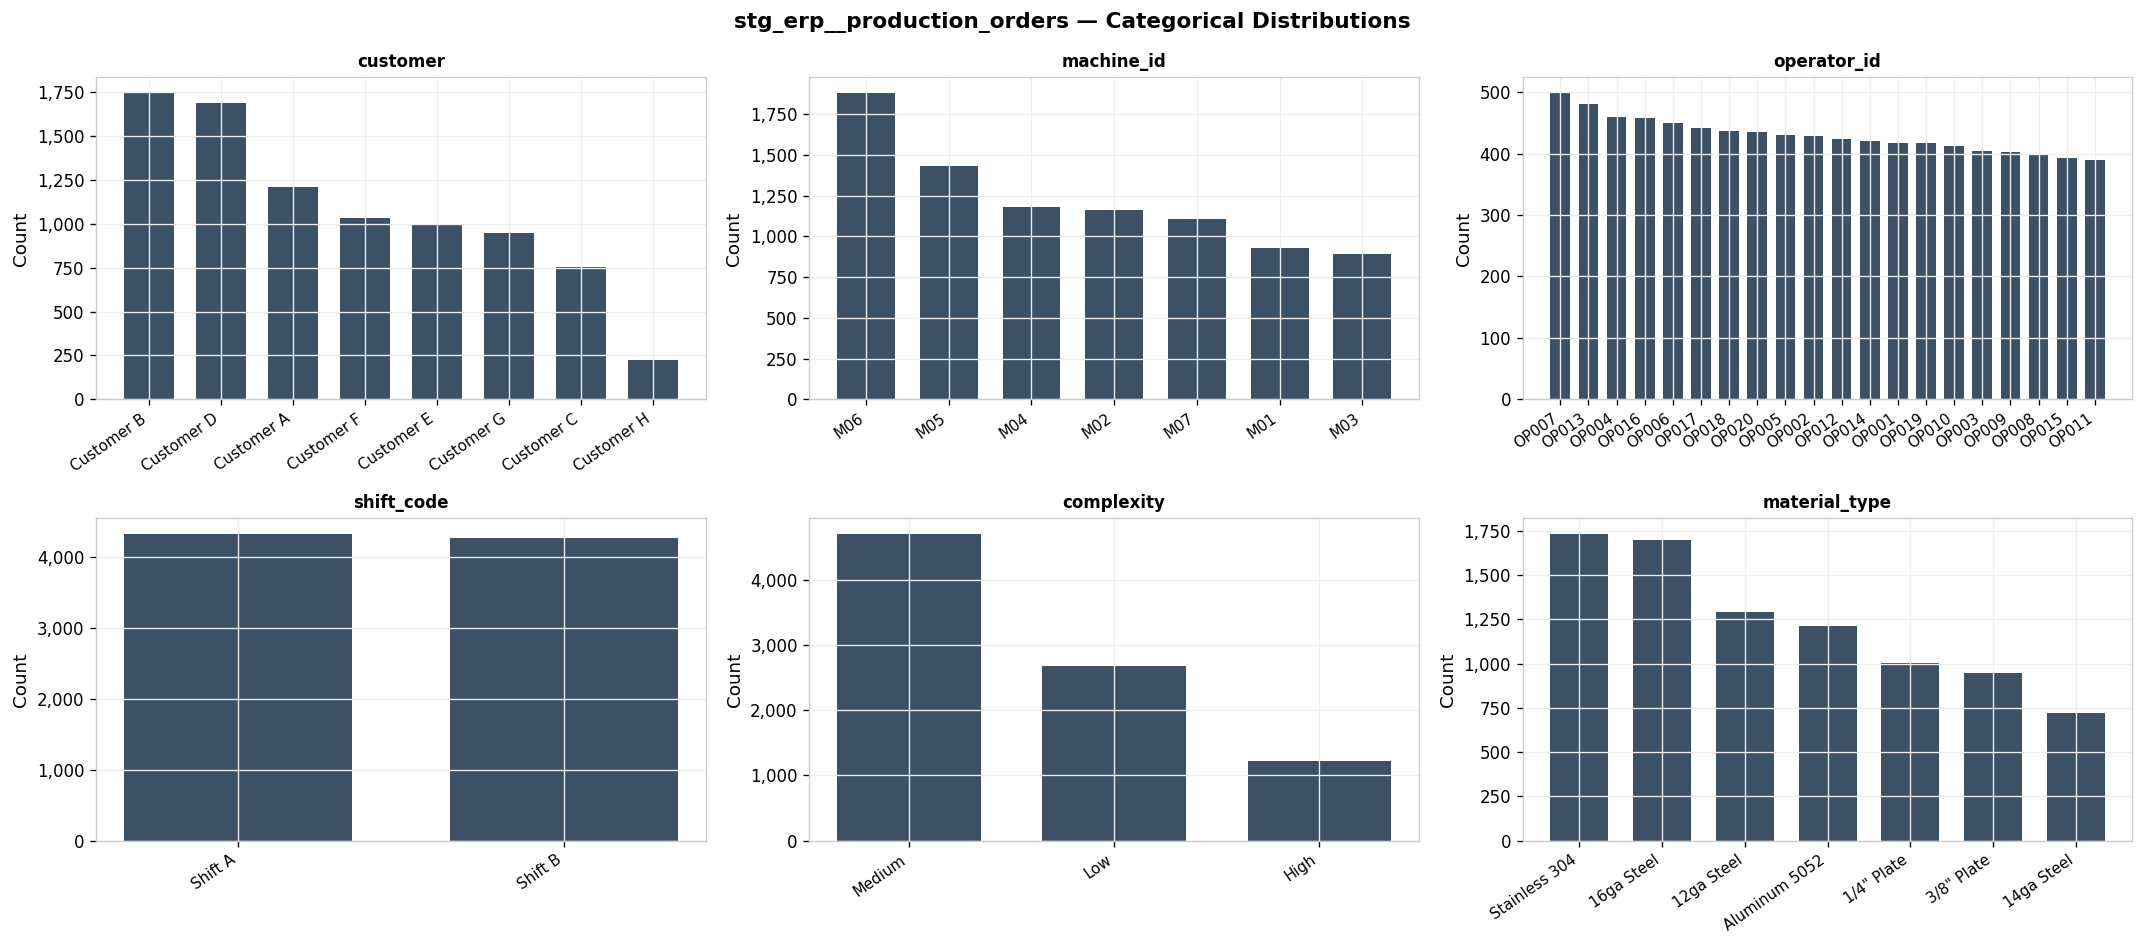

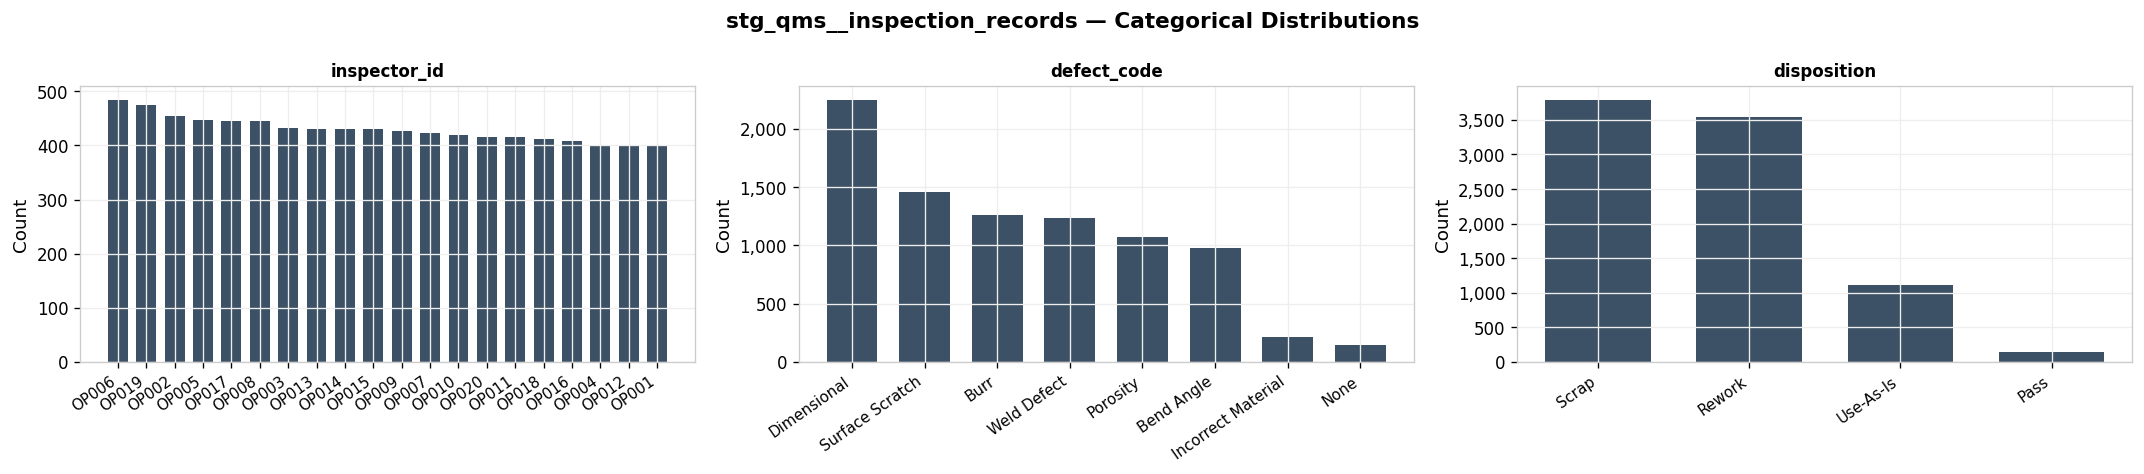

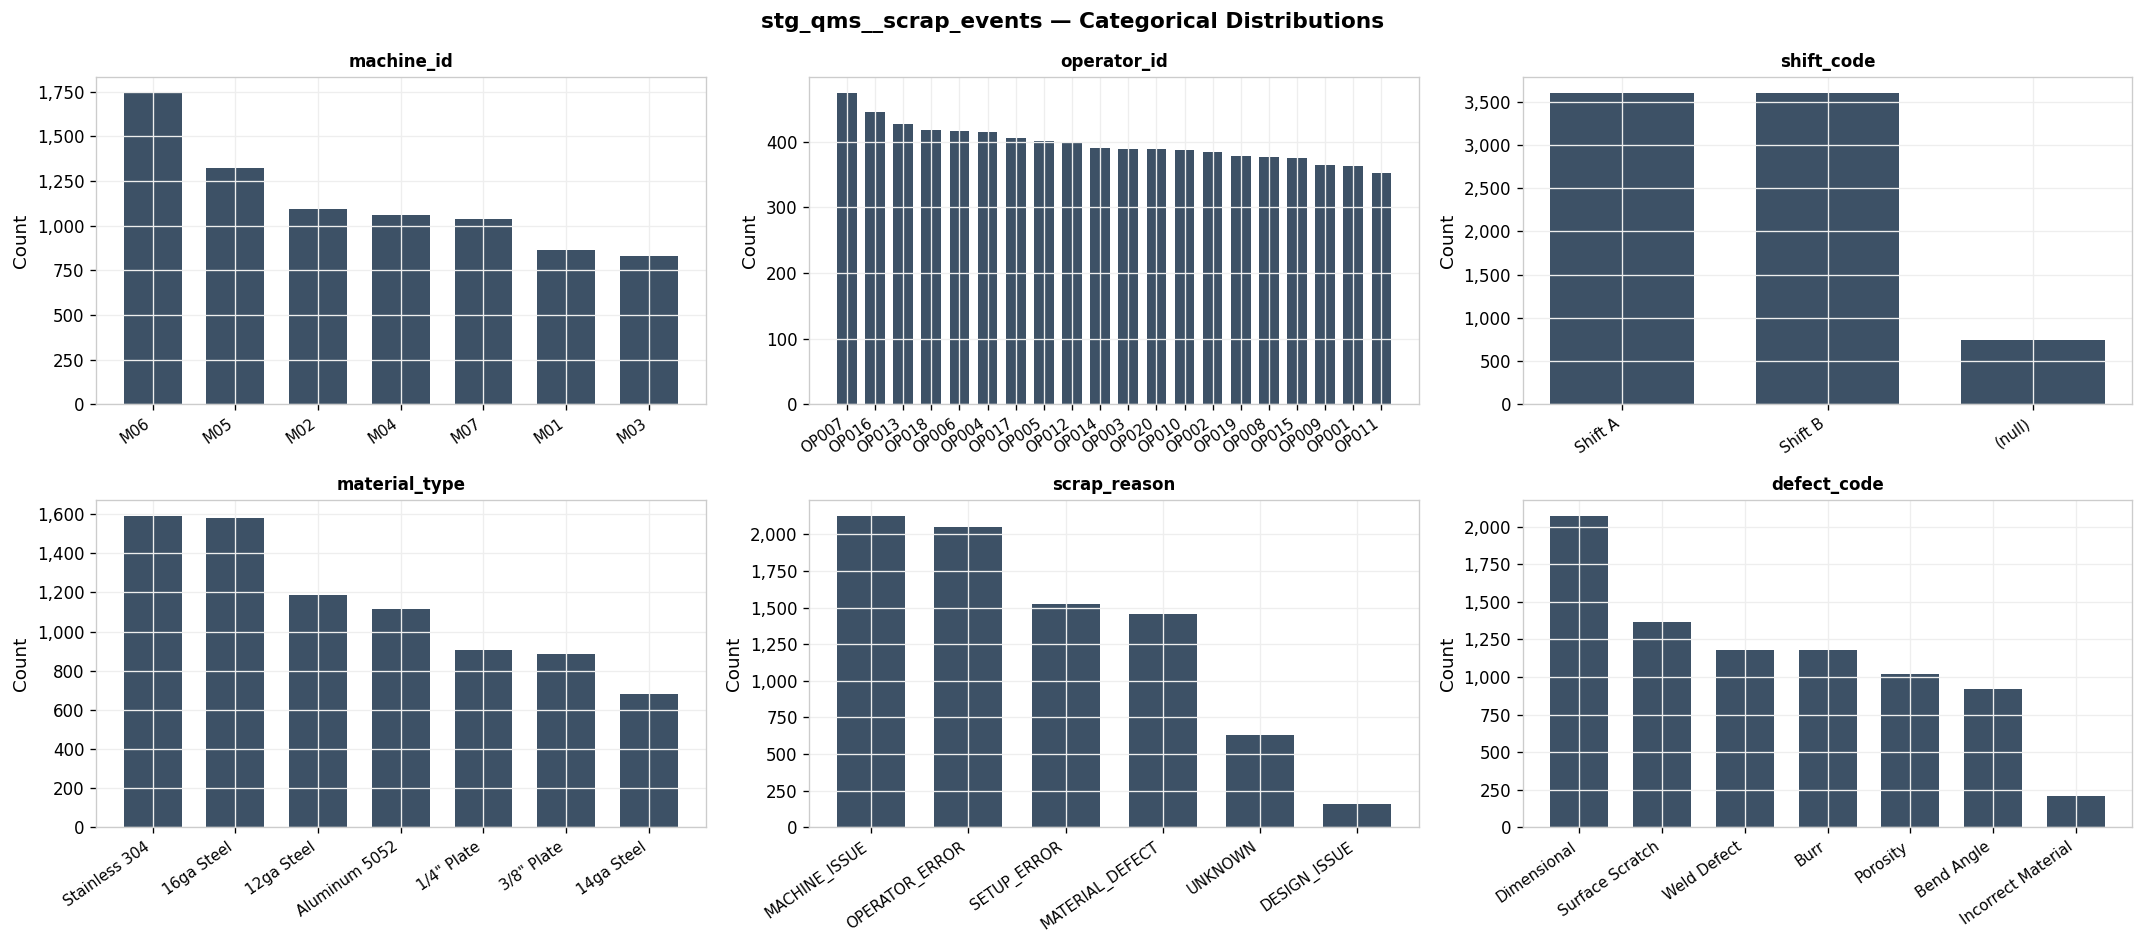

In [8]:
# Bar chart of value frequencies per categorical column per table.
for tbl, cols in CATEGORICAL_COLS.items():
    df = dfs[tbl]
    n  = len(cols)
    if n == 0:
        continue
    ncols_plot = min(n, 3)
    nrows_plot = (n + ncols_plot - 1) // ncols_plot
    fig, axes  = plt.subplots(nrows_plot, ncols_plot,
                               figsize=(6 * ncols_plot, 4 * nrows_plot))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        vc = df[col].fillna("(null)").value_counts()
        axes[i].bar(range(len(vc)), vc.values, color=BRAND_BLUE, width=0.7)
        axes[i].set_xticks(range(len(vc)))
        axes[i].set_xticklabels(vc.index, rotation=35, ha="right", fontsize=9)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel("Count")
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{tbl} — Categorical Distributions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 3.3 Correlation Matrices

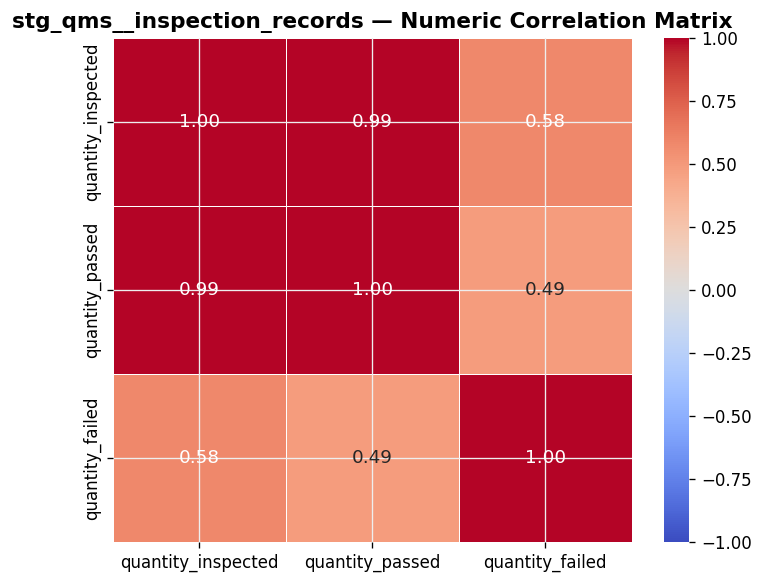

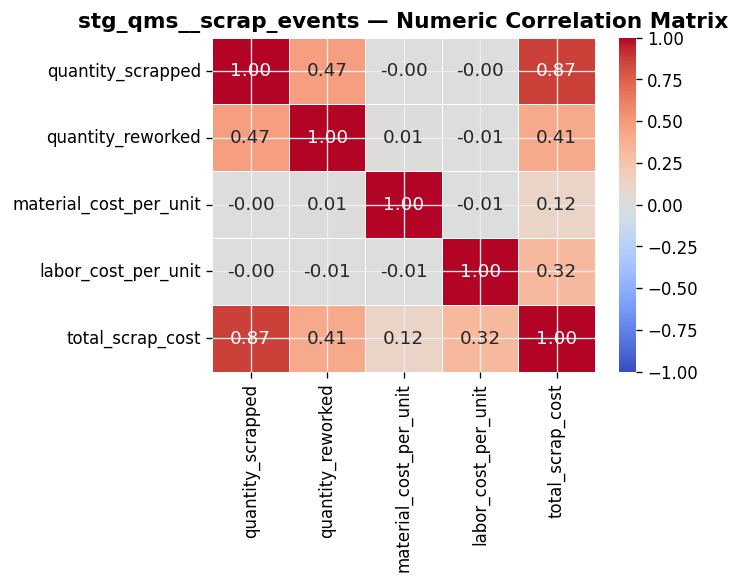

In [9]:
# Pearson correlation heatmap for tables with 3+ numeric columns.
for tbl, cols in NUMERIC_COLS.items():
    if len(cols) < 3:
        continue
    corr = dfs[tbl][cols].corr()
    fig, ax = plt.subplots(figsize=(max(6, len(cols) * 1.2), max(5, len(cols))))
    sns.heatmap(
        corr, ax=ax, annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        linewidths=0.5, linecolor="white",
        vmin=-1, vmax=1
    )
    ax.set_title(f"{tbl} — Numeric Correlation Matrix")
    plt.tight_layout()
    plt.show()

### 3.4 Time Series Analysis

Line chart with trend overlay and summary statistics for each table with a date column.

| Statistic | What it tells you |
|-----------|-------------------|
| Mean / Median | Central tendency; median is robust to spikes |
| Std dev + CV | Spread; CV (std/mean) enables cross-series volatility comparison |
| Min / Max (with dates) | Extremes and when they occurred |
| Trend slope | Direction and rate of change (linear regression, records/month) |
| Lag-1 autocorrelation | Does this month predict the next? High = momentum, low = noise |
| Seasonal strength | Consistency of within-year patterns across years (requires 2+ years) |

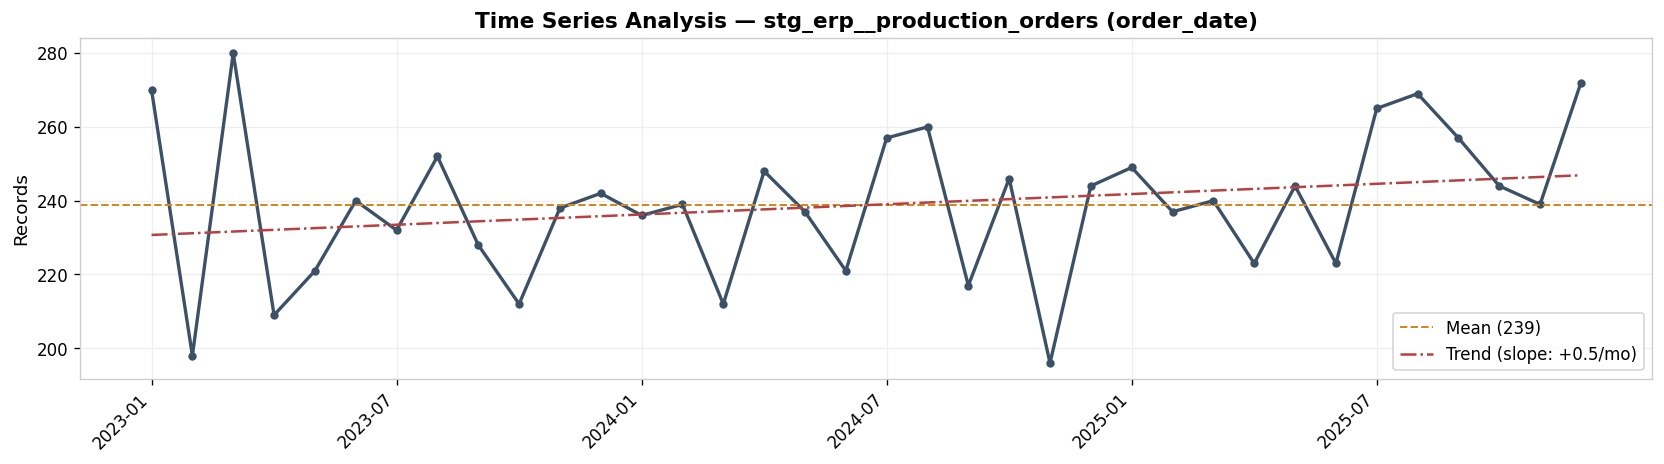

  stg_erp__production_orders — order_date
  ───────────────────────────────────────────────────────
  Mean:                               238.8
  Median:                             239.5
  Std dev:                             20.4
  CV (std/mean):                      0.086
  Min:                                  196  (2024-11)
  Max:                                  280  (2023-03)
  Trend slope (records/mo):           +0.46
  Lag-1 autocorrelation:             -0.302
  Seasonal strength:                  0.381  (strong)



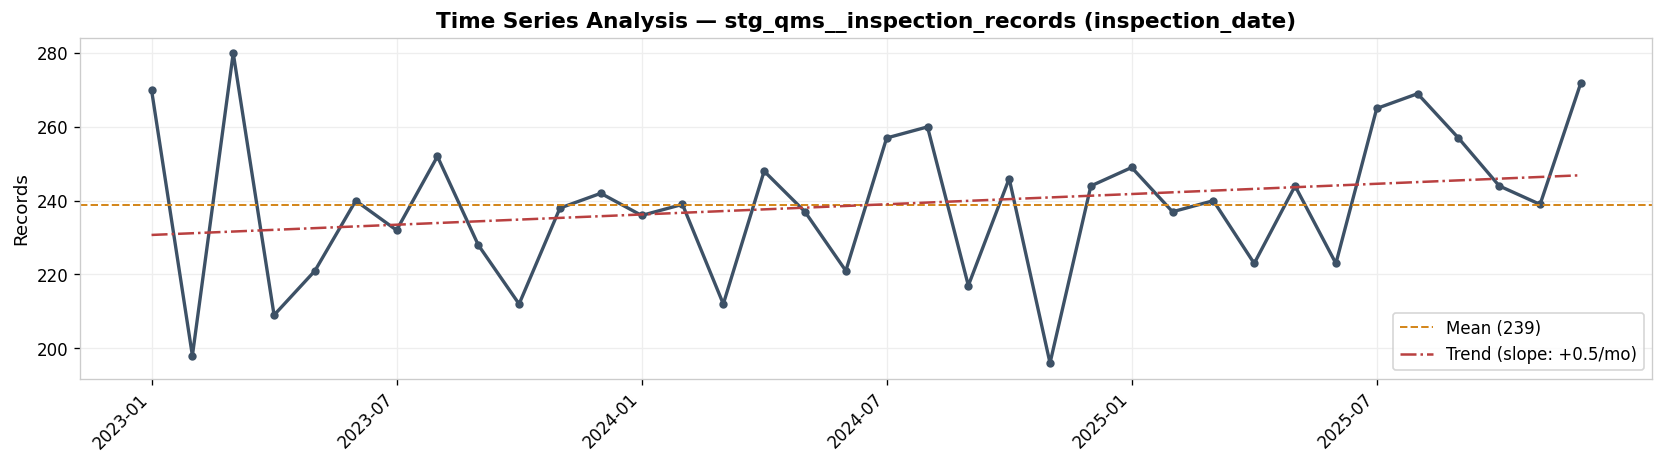

  stg_qms__inspection_records — inspection_date
  ───────────────────────────────────────────────────────
  Mean:                               238.8
  Median:                             239.5
  Std dev:                             20.4
  CV (std/mean):                      0.086
  Min:                                  196  (2024-11)
  Max:                                  280  (2023-03)
  Trend slope (records/mo):           +0.46
  Lag-1 autocorrelation:             -0.302
  Seasonal strength:                  0.381  (strong)



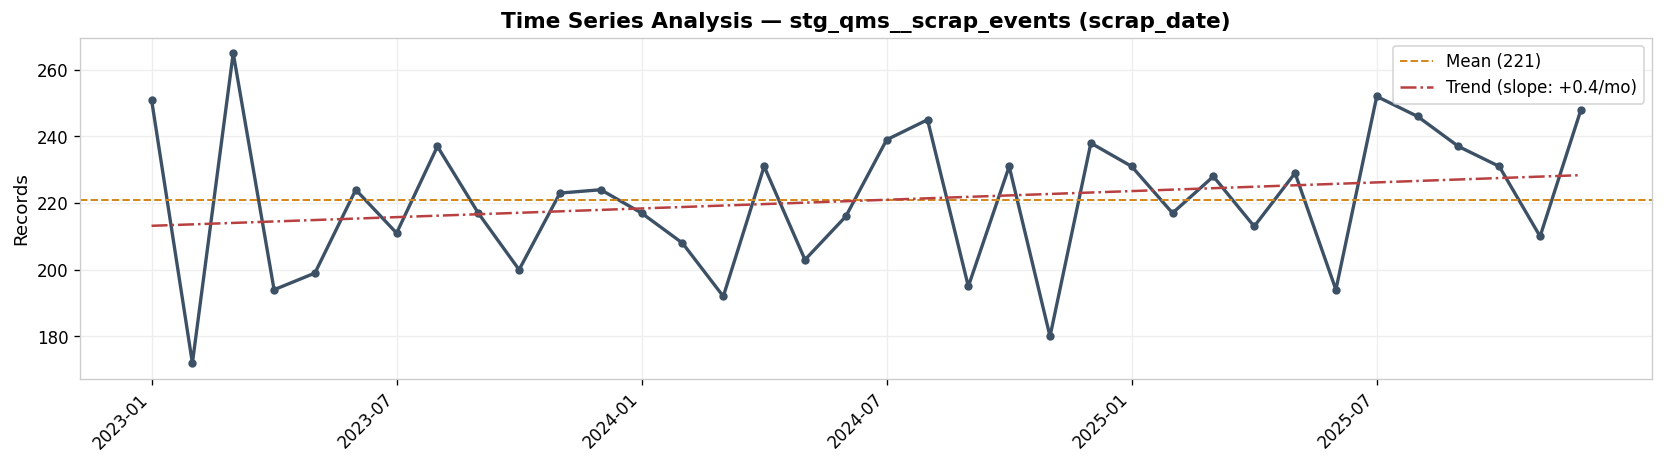

  stg_qms__scrap_events — scrap_date
  ───────────────────────────────────────────────────────
  Mean:                               220.8
  Median:                             223.5
  Std dev:                             21.5
  CV (std/mean):                      0.098
  Min:                                  172  (2023-02)
  Max:                                  265  (2023-03)
  Trend slope (records/mo):           +0.43
  Lag-1 autocorrelation:             -0.409
  Seasonal strength:                  0.420  (strong)



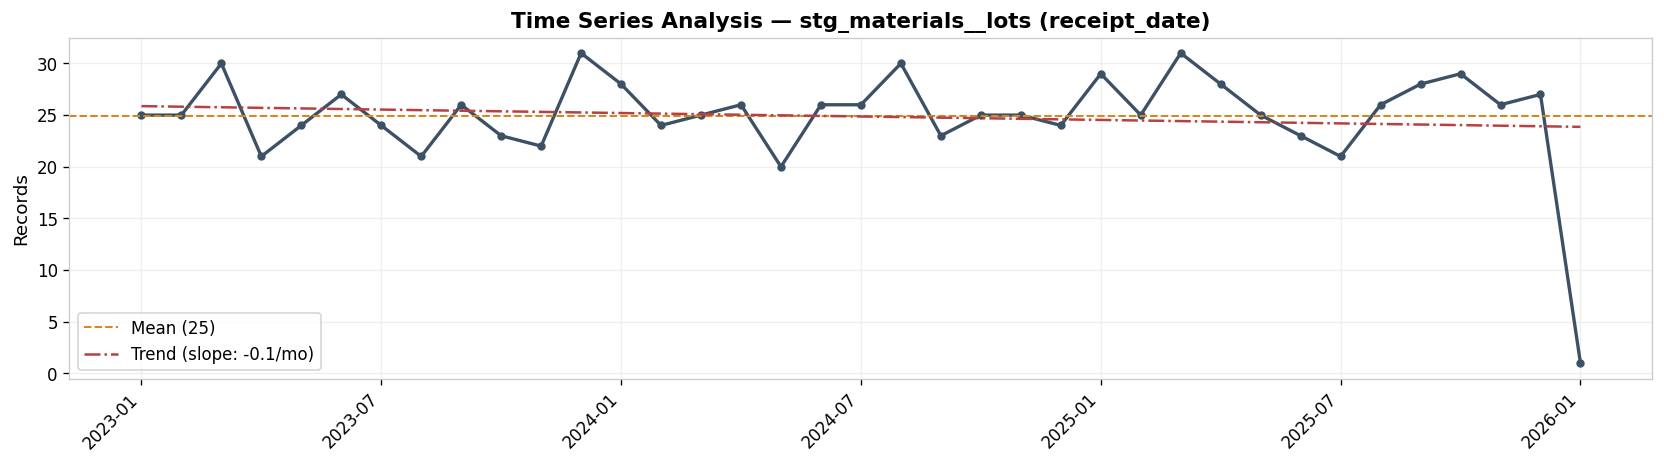

  stg_materials__lots — receipt_date
  ───────────────────────────────────────────────────────
  Mean:                                24.9
  Median:                              25.0
  Std dev:                              4.9
  CV (std/mean):                      0.198
  Min:                                    1  (2026-01)
  Max:                                   31  (2023-12)
  Trend slope (records/mo):           -0.06
  Lag-1 autocorrelation:             -0.079
  Seasonal strength:                  0.169  (weak)



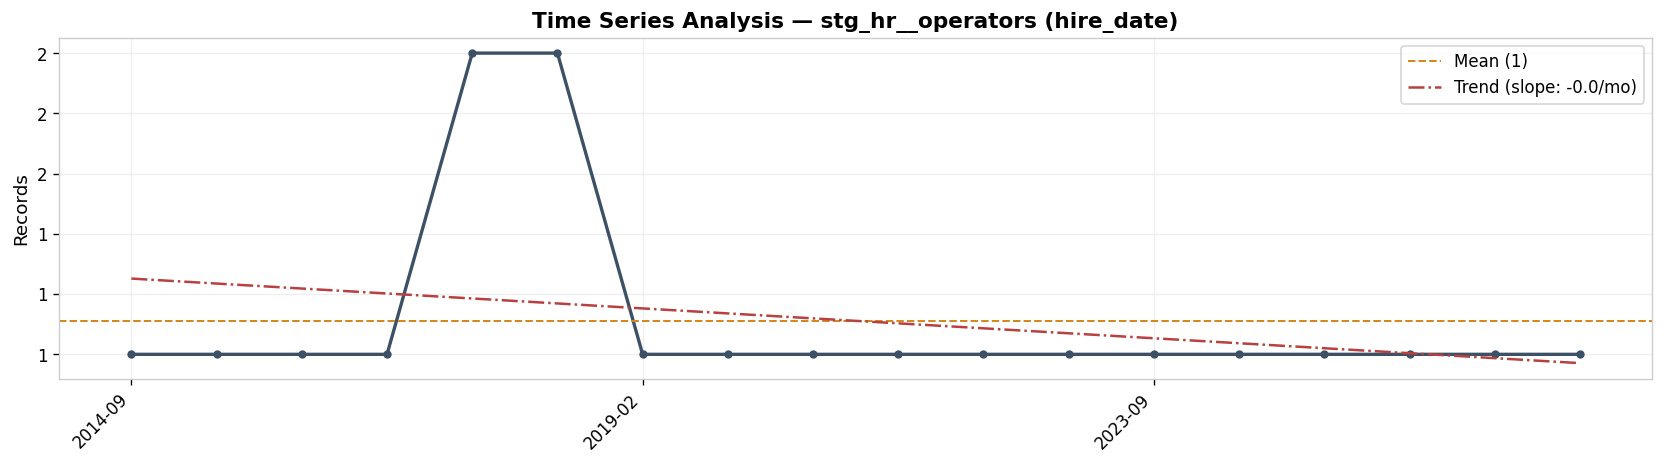

  stg_hr__operators — hire_date
  ───────────────────────────────────────────────────────
  Mean:                                 1.1
  Median:                               1.0
  Std dev:                              0.3
  CV (std/mean):                      0.291
  Min:                                    1  (2014-09)
  Max:                                    2  (2017-07)
  Trend slope (records/mo):           -0.02
  Lag-1 autocorrelation:              0.433
  Seasonal strength:             < 2 years of data



In [10]:
# Date columns — moved here from Section 1 as they are specific to this analysis.
DATE_COLUMNS = {
    TBL_STG_ORDERS:    ["order_date", "actual_start"],
    TBL_STG_INSP:      ["inspection_date"],
    TBL_STG_SCRAP:     ["scrap_date"],
    TBL_STG_LOTS:      ["receipt_date"],
    TBL_STG_OPERATORS: ["hire_date"],
}

for tbl, date_cols in DATE_COLUMNS.items():
    if tbl not in dfs:
        continue
    df       = dfs[tbl]
    date_col = next((c for c in date_cols if c in df.columns), None)
    if date_col is None:
        continue

    tmp           = df.copy()
    tmp["_dt"]    = pd.to_datetime(tmp[date_col], errors="coerce")
    tmp["_month"] = tmp["_dt"].dt.to_period("M")
    monthly       = tmp.groupby("_month").size().reset_index(name="records")
    monthly["ym"] = monthly["_month"].astype(str)
    s             = monthly["records"]

    if len(s) < 3:
        continue

    # ── Line chart ────────────────────────────────────────────────────────
    x_num                      = np.arange(len(s))
    slope, intercept, _, _, _  = linregress(x_num, s)
    trend                      = slope * x_num + intercept

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(monthly["ym"], s, color=BRAND_BLUE, linewidth=2, marker="o", markersize=4)
    ax.axhline(s.mean(), color=WARN_AMBER, linestyle="--", linewidth=1.2,
               label=f"Mean ({s.mean():,.0f})")
    ax.plot(monthly["ym"], trend, color=FAIL_RED, linewidth=1.5,
            linestyle="-.", label=f"Trend (slope: {slope:+.1f}/mo)")
    ax.set_title(f"Time Series Analysis — {tbl} ({date_col})")
    ax.set_ylabel("Records")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    xticks = monthly["ym"][::6]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Summary statistics ────────────────────────────────────────────────
    cv      = s.std() / s.mean() if s.mean() != 0 else None
    acf1    = s.autocorr(lag=1) if len(s) > 1 else None
    min_idx = s.idxmin()
    max_idx = s.idxmax()

    if len(monthly) >= 24:
        monthly["_moy"] = [p.month for p in monthly["_month"]]
        moy_means       = monthly.groupby("_moy")["records"].mean()
        between_var     = moy_means.var()
        total_var       = s.var()
        seasonal_str    = round(between_var / total_var, 3) if total_var > 0 else None
    else:
        seasonal_str = None

    print(f"  {tbl} — {date_col}")
    print(f"  {'─'*55}")
    print(f"  {'Mean:':<30} {s.mean():>10,.1f}")
    print(f"  {'Median:':<30} {s.median():>10,.1f}")
    print(f"  {'Std dev:':<30} {s.std():>10,.1f}")
    if cv is not None:
        print(f"  {'CV (std/mean):':<30} {cv:>10.3f}")
    print(f"  {'Min:':<30} {s.min():>10,.0f}  ({monthly.loc[min_idx, 'ym']})")
    print(f"  {'Max:':<30} {s.max():>10,.0f}  ({monthly.loc[max_idx, 'ym']})")
    print(f"  {'Trend slope (records/mo):':<30} {slope:>+10.2f}")
    if acf1 is not None:
        print(f"  {'Lag-1 autocorrelation:':<30} {acf1:>10.3f}")
    if seasonal_str is not None:
        label = 'strong' if seasonal_str > 0.3 else 'weak'
        print(f"  {'Seasonal strength:':<30} {seasonal_str:>10.3f}  ({label})")
    else:
        print(f"  {'Seasonal strength:':<30} {'< 2 years of data':>10}")
    print()

---
## 4. Structural Integrity Checks

### 4.1 Primary Key Validation

Staging models should produce fully deduplicated tables. Any PK violation means
staging deduplication logic is incomplete and must be fixed before mart models are built.

In [11]:
# Thresholds
JOIN_WARN_PCT = 100.0  # flag any join below 100% match rate

In [12]:
pk_flags = []

print(f"{'Table':<38} {'PK Column':<22} {'Total':>8}  {'Unique':>8}  "
      f"{'Dupes':>8}  {'Dup %':>7}  Status")
print("-" * 100)

for tbl, pk in PK_MAP.items():
    if tbl not in dfs:
        continue
    df = dfs[tbl]
    if pk not in df.columns:
        print(f"  ✗  {tbl:<35} {pk:<22} COLUMN MISSING")
        continue
    total   = len(df)
    unique  = df[pk].nunique()
    dupes   = total - unique
    dup_pct = dupes / total * 100
    status  = "✓ PASS" if dupes == 0 else "✗ FAIL"
    print(f"  {status[:1]}  {tbl:<35} {pk:<22} {total:>8,}  "
          f"{unique:>8,}  {dupes:>8,}  {dup_pct:>6.1f}%  {status}")
    if dupes > 0:
        pk_flags.append({
            "table": tbl, "column": pk,
            "issue": f"{dupes:,} duplicate rows ({dup_pct:.1f}%) after staging dedup"
        })

if pk_flags:
    print(f"\n✗ {len(pk_flags)} table(s) still have duplicate PKs. "
          "Fix dedup logic in staging models before proceeding.")

Table                                  PK Column                 Total    Unique     Dupes    Dup %  Status
----------------------------------------------------------------------------------------------------
  ✓  stg_mes__machines                   machine_id                    7         7         0     0.0%  ✓ PASS
  ✓  stg_hr__operators                   operator_id                  20        20         0     0.0%  ✓ PASS
  ✓  stg_materials__lots                 lot_id                      920       920         0     0.0%  ✓ PASS
  ✓  stg_erp__part_catalog               part_number                  35        35         0     0.0%  ✓ PASS
  ✓  stg_erp__production_orders          work_order_id             8,597     8,597         0     0.0%  ✓ PASS
  ✓  stg_qms__inspection_records         inspection_id             8,597     8,597         0     0.0%  ✓ PASS
  ✓  stg_qms__scrap_events               scrap_id                  7,948     7,948         0     0.0%  ✓ PASS


### 4.2 Referential Integrity & Join Viability

Tests FK relationships defined in `FK_RELATIONSHIPS`. Any join below 100% match
rate is flagged. Two metrics reported per relationship:
- **Distinct match rate** — % of unique FK values that resolve to a valid PK
- **Row-level match rate** — % of rows that survive a left join to the parent

In [13]:
ri_flags = []

def ri_check(child_tbl, child_col, parent_tbl, parent_col):
    child_df  = dfs.get(child_tbl)
    parent_df = dfs.get(parent_tbl)
    if child_df is None or parent_df is None:
        print(f"  ✗  SKIP  {child_tbl} or {parent_tbl} not loaded")
        return
    if child_col not in child_df.columns or parent_col not in parent_df.columns:
        print(f"  ✗  SKIP  Column missing in {child_tbl}.{child_col}")
        return

    child_vals     = set(child_df[child_col].dropna().unique())
    parent_vals    = set(parent_df[parent_col].dropna().unique())
    orphans        = child_vals - parent_vals
    distinct_match = (len(child_vals) - len(orphans)) / max(len(child_vals), 1) * 100

    merged    = child_df.merge(
        parent_df[[parent_col]].drop_duplicates(),
        left_on=child_col, right_on=parent_col, how="left", indicator=True
    )
    row_match = (merged["_merge"] == "both").mean() * 100
    status    = "✓ PASS" if row_match >= JOIN_WARN_PCT else "✗ FAIL"

    print(f"  {status}  {child_tbl}.{child_col} -> {parent_tbl}.{parent_col}")
    print(f"         Row match: {row_match:.1f}%   "
          f"Distinct match: {distinct_match:.1f}%   "
          f"Orphan values: {len(orphans):,}")
    if orphans:
        print(f"         Sample orphan values: {list(orphans)[:6]}")
    print()

    if row_match < JOIN_WARN_PCT:
        ri_flags.append({
            "table":  child_tbl, "column": child_col,
            "issue":  f"Row match {row_match:.1f}% -> {parent_tbl}.{parent_col} "
                      f"({len(orphans):,} orphan values)"
        })

print("REFERENTIAL INTEGRITY & JOIN VIABILITY")
print("=" * 70)
for child_tbl, child_col, parent_tbl, parent_col in FK_RELATIONSHIPS:
    ri_check(child_tbl, child_col, parent_tbl, parent_col)

REFERENTIAL INTEGRITY & JOIN VIABILITY
  ✓ PASS  stg_erp__production_orders.machine_id -> stg_mes__machines.machine_id
         Row match: 100.0%   Distinct match: 100.0%   Orphan values: 0

  ✓ PASS  stg_erp__production_orders.operator_id -> stg_hr__operators.operator_id
         Row match: 100.0%   Distinct match: 100.0%   Orphan values: 0

  ✓ PASS  stg_erp__production_orders.part_number -> stg_erp__part_catalog.part_number
         Row match: 100.0%   Distinct match: 100.0%   Orphan values: 0

  ✗ FAIL  stg_erp__production_orders.lot_id -> stg_materials__lots.lot_id
         Row match: 99.4%   Distinct match: 100.0%   Orphan values: 0

  ✓ PASS  stg_qms__inspection_records.work_order_id -> stg_erp__production_orders.work_order_id
         Row match: 100.0%   Distinct match: 100.0%   Orphan values: 0

  ✓ PASS  stg_qms__scrap_events.work_order_id -> stg_erp__production_orders.work_order_id
         Row match: 100.0%   Distinct match: 100.0%   Orphan values: 0

  ✗ FAIL  stg_qms__scr

### 4.3 FK Null Rates

FK columns should be fully populated unless explicitly declared as structural nulls
in `FK_NULLABLE`. Unexpected nulls indicate a staging join or derivation issue.

In [14]:
fk_null_flags = []

print(f"{'Relationship':<65} {'Null %':>8}  {'Structural':>12}  Status")
print("-" * 100)

for child_tbl, child_col, parent_tbl, parent_col in FK_RELATIONSHIPS:
    if child_tbl not in dfs or child_col not in dfs[child_tbl].columns:
        continue
    df          = dfs[child_tbl]
    null_pct    = df[child_col].isna().mean() * 100
    is_nullable = (child_tbl, child_col) in FK_NULLABLE
    status      = (
        "✓ PASS"   if null_pct == 0 else
        "✓ STRUCT" if is_nullable else
        "✗ FAIL"
    )
    rel = f"{child_tbl}.{child_col} -> {parent_tbl}.{parent_col}"
    print(f"  {status[:1]}  {rel:<63} {null_pct:>7.1f}%  "
          f"{'yes' if is_nullable else 'no':>12}  {status}")
    if null_pct > 0 and not is_nullable:
        fk_null_flags.append({
            "table":  child_tbl, "column": child_col,
            "issue":  f"FK null rate {null_pct:.1f}% — not declared in FK_NULLABLE"
        })

Relationship                                                        Null %    Structural  Status
----------------------------------------------------------------------------------------------------
  ✓  stg_erp__production_orders.machine_id -> stg_mes__machines.machine_id     0.0%            no  ✓ PASS
  ✓  stg_erp__production_orders.operator_id -> stg_hr__operators.operator_id     0.0%            no  ✓ PASS
  ✓  stg_erp__production_orders.part_number -> stg_erp__part_catalog.part_number     0.0%            no  ✓ PASS
  ✓  stg_erp__production_orders.lot_id -> stg_materials__lots.lot_id     0.6%           yes  ✓ STRUCT
  ✓  stg_qms__inspection_records.work_order_id -> stg_erp__production_orders.work_order_id     0.0%            no  ✓ PASS
  ✓  stg_qms__scrap_events.work_order_id -> stg_erp__production_orders.work_order_id     0.0%            no  ✓ PASS
  ✓  stg_qms__scrap_events.inspection_id -> stg_qms__inspection_records.inspection_id     0.0%            no  ✓ PASS


---
## 5. Additional Analyses

### 5.1 Numeric Range Validation

Confirms numeric columns fall within expected bounds after staging type casts.
Bounds defined in `NUMERIC_BOUNDS` (Section 1). Out-of-range values indicate
a data entry error in the source system or an unexpected staging cast result.

In [15]:
# ── Numeric bounds ───────────────────────────────
NUMERIC_BOUNDS = {
    TBL_STG_ORDERS: {
        "quantity_ordered": (1, None),
        "std_labor_hrs":    (0, None),
    },
    TBL_STG_INSP: {
        "quantity_inspected": (0, None),
        "quantity_passed":    (0, None),
        "quantity_failed":    (0, None),
    },
    TBL_STG_SCRAP: {
        "quantity_scrapped":      (0, None),
        "quantity_reworked":      (0, None),
        "material_cost_per_unit": (0, None),
        "labor_cost_per_unit":    (0, None),
        "total_scrap_cost":       (0, None),
    },
    TBL_STG_LOTS: {
        "quantity_lbs":     (1, None),
        "unit_cost_per_lb": (0, None),
    },
    TBL_STG_MACHINES: {
        "age_years": (0, 50),
    },
}
range_flags = []

print(f"{'Table':<38} {'Column':<25} {'Min':>10}  {'Max':>10}  "
      f"{'Violations':>12}  {'Viol %':>8}  Status")
print("-" * 115)

for tbl, col_bounds in NUMERIC_BOUNDS.items():
    if tbl not in dfs:
        continue
    df = dfs[tbl]
    for col, (lo, hi) in col_bounds.items():
        if col not in df.columns:
            print(f"  ✗  {tbl:<35} {col:<25} COLUMN MISSING")
            continue
        s         = df[col].dropna()
        lo_viol   = (s < lo).sum() if lo is not None else 0
        hi_viol   = (s > hi).sum() if hi is not None else 0
        viols     = lo_viol + hi_viol
        viol_pct  = viols / len(df) * 100
        status    = "✓ PASS" if viols == 0 else "✗ FAIL"
        bound_str = f"[{lo if lo is not None else '-inf'}, {hi if hi is not None else 'inf'}]"
        print(f"  {status[:1]}  {tbl:<35} {col:<25} "
              f"{s.min():>10,.2f}  {s.max():>10,.2f}  "
              f"{viols:>12,}  {viol_pct:>7.2f}%  {status}")
        if viols > 0:
            range_flags.append({
                "table":  tbl, "column": col,
                "issue":  f"{viols:,} values outside bounds {bound_str} "
                          f"(below: {lo_viol:,}, above: {hi_viol:,})"
            })

Table                                  Column                           Min         Max    Violations    Viol %  Status
-------------------------------------------------------------------------------------------------------------------
  ✓  stg_erp__production_orders          quantity_ordered               10.00      500.00             0     0.00%  ✓ PASS
  ✓  stg_erp__production_orders          std_labor_hrs                   0.62        4.93             0     0.00%  ✓ PASS
  ✓  stg_qms__inspection_records         quantity_inspected             10.00      500.00             0     0.00%  ✓ PASS
  ✓  stg_qms__inspection_records         quantity_passed                 4.00      484.00             0     0.00%  ✓ PASS
  ✓  stg_qms__inspection_records         quantity_failed                 0.00      253.00             0     0.00%  ✓ PASS
  ✓  stg_qms__scrap_events               quantity_scrapped               0.00      191.00             0     0.00%  ✓ PASS
  ✓  stg_qms__scrap_events      

### 5.2 Temporal Gap Detection

Checks for missing periods in time series data. A gap is defined as a calendar
month with zero records that falls within the overall date range of the table.
Uses the same `DATE_COLUMNS` config defined in Section 4.4.

In [16]:
temporal_flags = []

for tbl, date_cols in DATE_COLUMNS.items():
    if tbl not in dfs:
        continue
    df       = dfs[tbl]
    date_col = next((c for c in date_cols if c in df.columns), None)
    if date_col is None:
        continue

    parsed = pd.to_datetime(df[date_col], errors="coerce")
    if parsed.isna().all():
        continue

    periods  = parsed.dt.to_period("M").dropna()
    min_per  = periods.min()
    max_per  = periods.max()
    expected = pd.period_range(min_per, max_per, freq="M")
    observed = set(periods.unique())
    missing  = [p for p in expected if p not in observed]

    if missing:
        print(f"  ⚠  {tbl}.{date_col}  —  {len(missing)} missing month(s) "
              f"in range {min_per} to {max_per}:")
        for p in missing:
            print(f"       {p}")
        temporal_flags.append({
            "table":  tbl, "column": date_col,
            "issue":  f"{len(missing)} missing month(s): "
                      f"{[str(p) for p in missing[:5]]}"
        })
    else:
        print(f"  ✓  {tbl}.{date_col}  —  no gaps detected "
              f"({min_per} to {max_per}, {len(expected)} months)")

  ✓  stg_erp__production_orders.order_date  —  no gaps detected (2023-01 to 2025-12, 36 months)
  ✓  stg_qms__inspection_records.inspection_date  —  no gaps detected (2023-01 to 2025-12, 36 months)


  ✓  stg_qms__scrap_events.scrap_date  —  no gaps detected (2023-01 to 2025-12, 36 months)
  ✓  stg_materials__lots.receipt_date  —  no gaps detected (2023-01 to 2026-01, 37 months)
  ⚠  stg_hr__operators.hire_date  —  121 missing month(s) in range 2014-09 to 2026-03:
       2014-10
       2014-11
       2014-12
       2015-01
       2015-02
       2015-03
       2015-04
       2015-05
       2015-06
       2015-07
       2015-08
       2015-09
       2015-10
       2015-11
       2015-12
       2016-01
       2016-02
       2016-03
       2016-04
       2016-05
       2016-06
       2016-07
       2016-08
       2016-09
       2016-10
       2016-12
       2017-01
       2017-03
       2017-05
       2017-06
       2017-08
       2017-09
       2017-10
       2017-11
       2017-12
       2018-01
       2018-03
       2018-04
       2018-05
       2018-06
       2018-07
       2018-08
       2018-09
       2018-10
       2018-11
       2018-12
       2019-01
       2019-03
       2019